# 12 — Análisis exploratorio del conjunto de datos

Esta notebook caracteriza el conjunto construido en `11-dataset_training.ipynb` antes del modelado. El análisis se organiza en torno a cinco preguntas que condicionan decisiones posteriores: cómo se distribuyen los positivos a lo largo del día y del año (Sección 1), qué tan heterogénea es la frecuencia de eventos entre estaciones (Sección 2), cuántos eventos independientes respaldan cada período (Sección 3), en qué se diferencian los dos grupos de negativos de entrenamiento (Sección 4) y si la señal satelital distingue a los positivos de los negativos, tanto en la imagen de $t$ como en su evolución durante la media hora previa (Sección 5).

Las Secciones 1 a 3 describen la composición de la etiqueta en los tres períodos, que se conoce desde la construcción del conjunto. La Sección 5, en cambio, se restringe al período de entrenamiento, de modo que ninguna observación sobre la relación entre la imagen y la etiqueta provenga de los datos con los que se seleccionan y evalúan los modelos. Todas las horas se expresan en hora local (America/Bogota).

Los pares considerados son los que efectivamente intervienen en el modelado: en entrenamiento, los que disponen de la historia mínima de dos imágenes ($L_{max} \geq 2$); en validación y prueba, los que disponen de la historia completa de cuatro imágenes ($L_{max} = 4$).

**Output**

|Archivo|Descripción|
|-|-|
|`img-eda-ciclo_diurno.png`|Tasa y distribución horaria de los positivos por período|
|`img-eda-ciclo_estacional.png`|Positivos y tasa de positivos por mes|
|`img-eda-estaciones.png`|Tasa de positivos por estación frente al umbral y entre años|
|`img-eda-episodios.png`|Duración, extensión espacial y frecuencia mensual de los episodios|
|`img-eda-negativos.png`|Características de los negativos near-miss y aleatorios|
|`img-eda-bt_distribucion.png`|Temperatura de brillo de los parches por grupo y banda|
|`img-eda-bt_diferencia.png`|Diferencia media de temperatura de brillo entre grupos|
|`img-eda-bt_evolucion.png`|Evolución de la temperatura de brillo en la media hora previa a $t$|
|`img-eda-ejemplos.png`|Parches de ejemplo por grupo|
|`data/eda_parches_muestra.npz`|Parches de la muestra de la Sección 5, para no releer las imágenes al re-ejecutar|

In [1]:
import sys, pathlib
_raiz = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / ".gitignore").exists())
sys.path.insert(0, str(_raiz))
import entorno

In [2]:
# ============================================================
# Configuración
# ============================================================
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
from matplotlib.patches import Patch

RUTA_BASE   = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_GT     = RUTA_BASE / "data_ingestion" / "ground_truth"
RUTA_SAT    = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_INDICE = RUTA_BASE / "datasets" / "indice_completo.parquet"
RUTA_UMBRAL = RUTA_GT / "umbral_operativo_por_estacion.csv"
RUTA_INV    = RUTA_SAT / "inventario_goes.parquet"

sys.path.append(str(RUTA_BASE / "src"))
from paleta import PALETA, ROL, aplicar_estilo
from etiquetado import TZ, PASO_MIN
aplicar_estilo()

ORDEN   = ["train", "val", "test"]
CORTES  = {"val": pd.Timestamp("2024-11-15", tz=TZ), "test": pd.Timestamp("2025-01-01", tz=TZ)}
L_MAX   = 4
paso    = pd.Timedelta(minutes=PASO_MIN)
BANDAS  = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
MITAD   = 16                                   # parche de 32×32 píxeles (64 km)
SEED    = 42
MIN_EST = 5                                    # día regional: positivos en al menos 5 estaciones
COL_PER = {"train": ROL["serie"], "val": ROL["corte_val"], "test": ROL["corte_test"]}

indice = pd.read_parquet(RUTA_INDICE)
assert str(indice["timestamp"].dt.tz) == "UTC"
assert indice["etiqueta"].notna().all()
indice["etiqueta"] = indice["etiqueta"].astype("int8")
assert (len(indice), int(indice["etiqueta"].sum())) == (4_029_925, 18_229)

indice["t_local"] = indice["timestamp"].dt.tz_convert(TZ)
indice["hora"]    = indice["t_local"].dt.hour
indice["dia"]     = indice["t_local"].dt.date
indice["mes"]     = indice["t_local"].dt.tz_localize(None).dt.to_period("M")

# Pares en uso: entrenamiento con la historia mínima; validación y prueba con la historia completa
uso = indice[(indice["periodo"] == "train") | (indice["L_max"] == L_MAX)].copy()
assert len(uso) == 1_247_317 + 331_916 + 2_442_338

umbrales = pd.read_csv(RUTA_UMBRAL, dtype={"codigoestacion": str}).set_index("codigoestacion")

resumen_uso = (uso.groupby("periodo")
                  .agg(pares=("etiqueta", "size"), positivos=("etiqueta", "sum"),
                       dias=("dia", "nunique"), estaciones=("codigoestacion", "nunique"))
                  .reindex(ORDEN)
                  .assign(prevalencia=lambda d: (d["positivos"] / d["pares"]).map("{:.3%}".format)))
print(resumen_uso.to_string())

           pares  positivos  dias  estaciones prevalencia
periodo                                                  
train    1247317       4255   265          62      0.341%
val       331916       1542    47          63      0.465%
test     2442338      12367   343          63      0.506%


**Composición del conjunto**

Antes de examinar su estructura temporal y espacial, se resume la composición del conjunto en los tres períodos: el número de pares de cada clase, el desbalance entre ellas y, en entrenamiento, el tamaño de los dos grupos de negativos definidos en 11-dataset_training.ipynb.

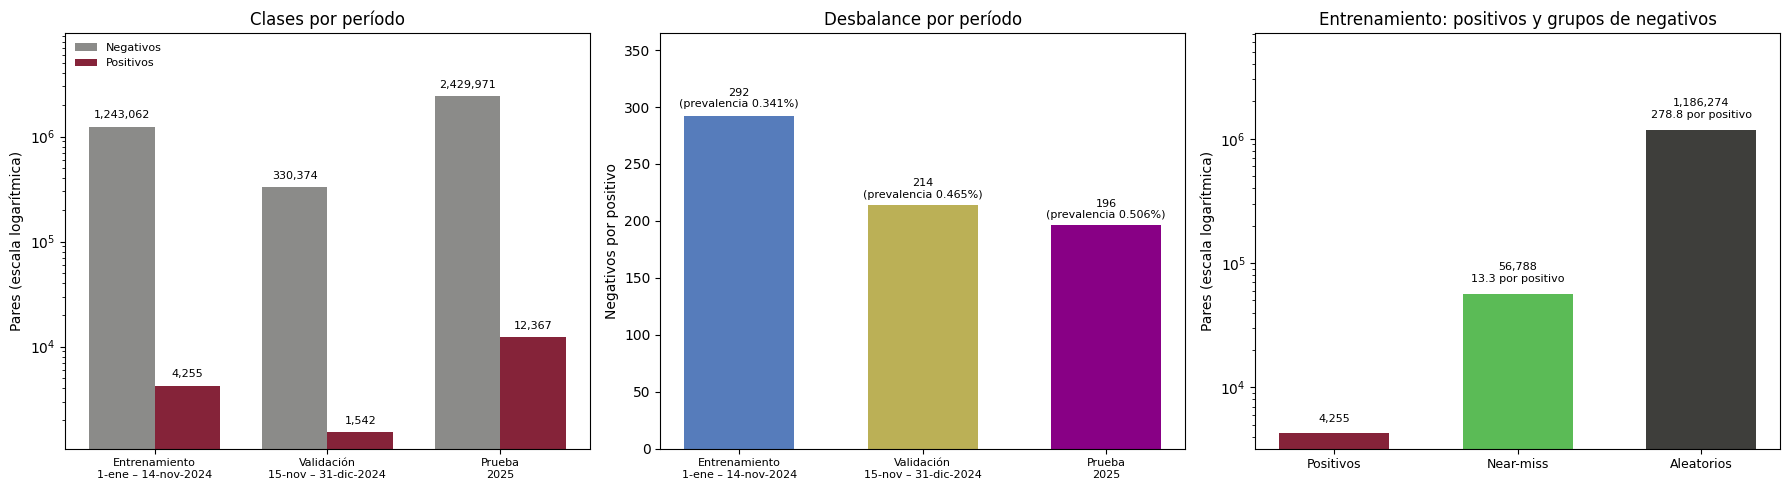

           pares  positivos  negativos prevalencia  neg_por_pos
periodo                                                        
train    1247317       4255    1243062      0.341%          292
val       331916       1542     330374      0.465%          214
test     2442338      12367    2429971      0.506%          196

Total: 4,021,571 pares, 18,164 positivos (prevalencia 0.452%)

Grupos de entrenamiento:
             pares  por_positivo
pool                            
positivo      4255           1.0
near_miss    56788          13.3
aleatorio  1186274         278.8


In [45]:
# ============================================================
# Composición del conjunto
# ============================================================
comp = uso.groupby("periodo")["etiqueta"].agg(pares="size", positivos="sum").reindex(ORDEN)
comp["negativos"]    = comp["pares"] - comp["positivos"]
comp["prevalencia"]  = comp["positivos"] / comp["pares"]
comp["neg_por_pos"]  = comp["negativos"] / comp["positivos"]
grupos_tr = uso.loc[uso["periodo"] == "train", "pool"].value_counts().reindex(["positivo", "near_miss", "aleatorio"])

ETQ_PER = ["Entrenamiento\n1-ene – 14-nov-2024", "Validación\n15-nov – 31-dic-2024", "Prueba\n2025"]
COL_POOL = {"positivo": ROL["positivo"], "near_miss": ROL["estacional"], "aleatorio": ROL["linea_ref"]}
x = np.arange(len(ORDEN))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax, w = axes[0], 0.38
ax.bar(x - w / 2, comp["negativos"], w, color=ROL["linea_ref"], alpha=0.6, label="Negativos")
ax.bar(x + w / 2, comp["positivos"], w, color=ROL["positivo"], label="Positivos")
for i, (n, p) in enumerate(zip(comp["negativos"], comp["positivos"])):
    ax.text(i - w / 2, n * 1.2, f"{n:,}", ha="center", fontsize=8)
    ax.text(i + w / 2, p * 1.2, f"{p:,}", ha="center", fontsize=8)
ax.set_yscale("log"); ax.set_ylim(top=comp["negativos"].max() * 4)
ax.set_xticks(x); ax.set_xticklabels(ETQ_PER, fontsize=8)
ax.set_ylabel("Pares (escala logarítmica)"); ax.set_title("Clases por período")
ax.legend(fontsize=8, frameon=False, loc="upper left")

ax = axes[1]
ax.bar(x, comp["neg_por_pos"], color=[COL_PER[p] for p in ORDEN], width=0.6)
for i, (r, prev) in enumerate(zip(comp["neg_por_pos"], comp["prevalencia"])):
    ax.text(i, r * 1.02, f"{r:.0f}\n(prevalencia {prev:.3%})", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, comp["neg_por_pos"].max() * 1.25)
ax.set_xticks(x); ax.set_xticklabels(ETQ_PER, fontsize=8)
ax.set_ylabel("Negativos por positivo"); ax.set_title("Desbalance por período")

ax = axes[2]
ax.bar(range(3), grupos_tr, color=[COL_POOL[g] for g in grupos_tr.index], width=0.6)
for i, (g, n) in enumerate(grupos_tr.items()):
    extra = "" if g == "positivo" else f"\n{n / grupos_tr['positivo']:.1f} por positivo"
    ax.text(i, n * 1.2, f"{n:,}{extra}", ha="center", va="bottom", fontsize=8)
ax.set_yscale("log"); ax.set_ylim(top=grupos_tr.max() * 6)
ax.set_xticks(range(3)); ax.set_xticklabels(["Positivos", "Near-miss", "Aleatorios"], fontsize=9)
ax.set_ylabel("Pares (escala logarítmica)"); ax.set_title("Entrenamiento: positivos y grupos de negativos")

plt.tight_layout()
fig.savefig("img-eda-composicion.png", dpi=200, bbox_inches="tight")
plt.show()

print(comp.assign(prevalencia=lambda d: d["prevalencia"].map("{:.3%}".format),
                  neg_por_pos=lambda d: d["neg_por_pos"].round(0).astype(int)).to_string())
tot = comp[["pares", "positivos"]].sum()
print(f"\nTotal: {tot['pares']:,} pares, {tot['positivos']:,} positivos (prevalencia {tot['positivos'] / tot['pares']:.3%})")
print("\nGrupos de entrenamiento:")
print(grupos_tr.to_frame("pares").assign(por_positivo=lambda d: (d["pares"] / d.loc["positivo", "pares"]).round(1)).to_string())

**Resultado.** El conjunto que interviene en el modelado reúne 4,021,571 pares y 18,164 positivos, con una prevalencia global de 0.452%. El desbalance disminuye de un período al siguiente: el entrenamiento cuenta 292 negativos por cada positivo (prevalencia de 0.341%), la validación 214 (0.465%) y la prueba 196 (0.506%), en coherencia con el carácter más lluvioso de 2025 (Sección 1). En entrenamiento, los negativos se dividen en 56,788 near-miss, 13.3 por cada positivo, y 1,186,274 aleatorios, 278.8 por positivo. Los near-miss representan así menos del 5% de los negativos de entrenamiento, aunque son los únicos que comparten con los positivos la escena convectiva (Secciones 4 y 5).

In [46]:
# Cifras citadas en el texto de la composición del conjunto
assert comp["pares"].tolist() == [1_247_317, 331_916, 2_442_338]
assert comp["positivos"].tolist() == [4255, 1542, 12367]
assert (tot["pares"], tot["positivos"], f"{tot['positivos'] / tot['pares']:.3%}") == (4_021_571, 18_164, "0.452%")
assert comp["neg_por_pos"].round(0).astype(int).tolist() == [292, 214, 196]
assert comp["prevalencia"].map("{:.3%}".format).tolist() == ["0.341%", "0.465%", "0.506%"]
assert grupos_tr.tolist() == [4255, 56_788, 1_186_274]
assert round(grupos_tr["near_miss"] / (grupos_tr["near_miss"] + grupos_tr["aleatorio"]) * 100, 1) < 5
print("Cifras de la composición verificadas")

Cifras de la composición verificadas


## Sección 1 — Ciclo diurno y estacional de los positivos

La etiqueta de un par se refiere a la lluvia de las tres horas siguientes a $t$, de modo que el ciclo diurno de los positivos, expresado según la hora de la imagen, debe aparecer desplazado entre una y tres horas antes que el de la lluvia fuerte. Casallas-García et al. (2023) sitúan el máximo de la convección sobre la Sabana a inicios de la tarde (14:00–15:00, hora local), por lo que los positivos deberían concentrarse en imágenes tomadas hacia el mediodía. La comparación entre períodos indica, además, si el entrenamiento, la validación y la prueba comparten la misma estructura diurna, condición para que el desempeño medido en los dos últimos sea representativo del modelo.

El ciclo estacional se examina por mes, con el número de positivos de cada período y la prevalencia mensual. Los meses con pocos pares utilizables, por cortes que afectan a toda la red, se señalan para no confundir la falta de datos con la ausencia de eventos.

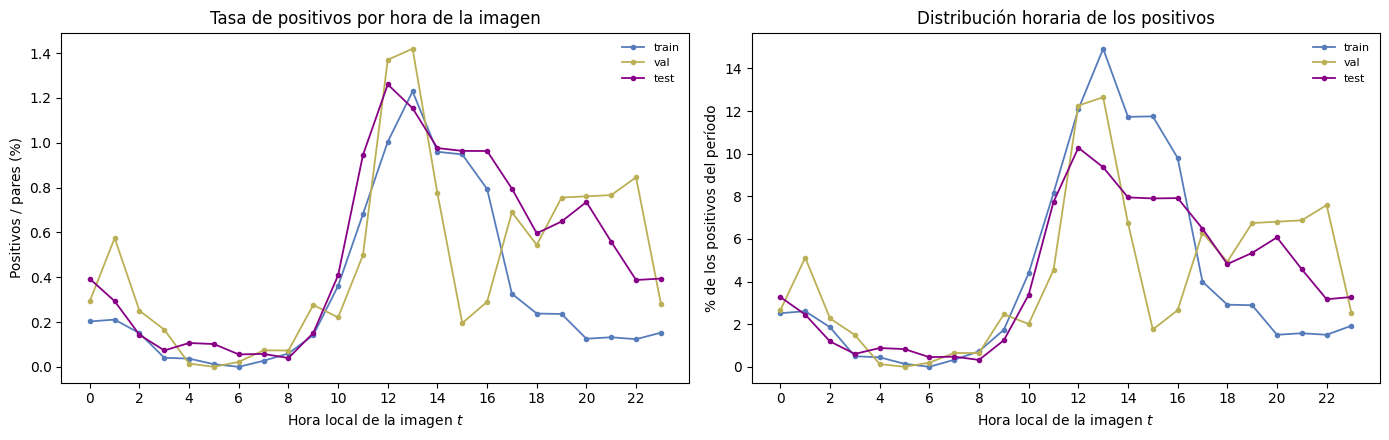

       hora_pico  %_en_pico  %_entre_10_y_15h  %_entre_19_y_06h                                         horas_80%
train         13       14.9              63.0              17.5          [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
val           13       12.6              39.9              42.4       [1, 11, 12, 13, 14, 17, 18, 19, 20, 21, 22]
test          12       10.3              46.6              32.1  [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [ ]:
# ============================================================
# Sección 1 — Ciclo diurno
# ============================================================
HORAS = range(24)
por_hora = (uso.groupby(["periodo", "hora"])["etiqueta"]
               .agg(pares="size", positivos="sum"))
tasa_h = (por_hora["positivos"] / por_hora["pares"]).unstack("periodo").reindex(index=HORAS, columns=ORDEN)
frac_h = (por_hora["positivos"] / por_hora.groupby("periodo")["positivos"].transform("sum")
          ).unstack("periodo").reindex(index=HORAS, columns=ORDEN).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for p in ORDEN:
    axes[0].plot(tasa_h.index, tasa_h[p] * 100, "o-", ms=3, lw=1.3, color=COL_PER[p], label=p)
    axes[1].plot(frac_h.index, frac_h[p] * 100, "o-", ms=3, lw=1.3, color=COL_PER[p], label=p)
axes[0].set_ylabel("Positivos / pares (%)")
axes[0].set_title("Tasa de positivos por hora de la imagen")
axes[1].set_ylabel("% de los positivos del período")
axes[1].set_title("Distribución horaria de los positivos")
for ax in axes:
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel("Hora local de la imagen $t$")
    ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

def horas_que_reunen(frac, q):
    # Menor conjunto de horas que reúne la fracción q de los positivos
    orden = frac.sort_values(ascending=False)
    return sorted(orden.index[: int((orden.cumsum() < q).sum()) + 1])

resumen_h = pd.DataFrame({
    "hora_pico": frac_h.idxmax(),
    "%_en_pico": (frac_h.max() * 100).round(1),
    "%_entre_10_y_15h": (frac_h.loc[10:15].sum() * 100).round(1),
    "%_entre_19_y_06h": ((frac_h.loc[19:23].sum() + frac_h.loc[0:6].sum()) * 100).round(1),
    "horas_80%": [horas_que_reunen(frac_h[p], 0.8) for p in ORDEN],
}, index=ORDEN)
print(resumen_h.to_string())

**Resultado — ciclo diurno.** En el conjunto de entrenamiento, los positivos se concentran en las imágenes tomadas entre las 10:00 y las 15:00, hora local, que reúnen el 63.0% del total, con un máximo a las 13:00 (14.9%). Dado que la ventana de la etiqueta abarca de una a tres horas después de $t$, la imagen de las 13:00 anticipa la lluvia de las 14:00 a las 16:00, en coherencia con el máximo de la convección sobre la Sabana a inicios de la tarde (14:00–15:00) descrito por Casallas-García et al. (2023). La tasa de positivos sigue el mismo patrón: es prácticamente nula en las imágenes de la madrugada y alcanza su máximo en las del mediodía.

La validación y la prueba comparten el máximo del mediodía, con picos a las 13:00 y a las 12:00, respectivamente, pero presentan una segunda moda, entre el final de la tarde y la noche, que en el entrenamiento es mucho más débil. Las imágenes tomadas entre las 19:00 y las 06:00 reúnen el 17.5% de los positivos de entrenamiento, frente al 42.4% en validación y el 32.1% en prueba, de modo que en estos dos períodos el 80% de los positivos se reparte entre el mediodía y las 21:00–22:00. La literatura revisada sobre la Sabana se centra en la convección diurna de las temporadas de lluvia (Casallas-García et al., 2023) y no caracteriza la lluvia fuerte nocturna, por lo que su origen no se examina en este trabajo. La consecuencia para el modelado es que el modelo aprende principalmente de escenas de la tarde y se evalúa sobre un conjunto en que los eventos nocturnos tienen un peso considerablemente mayor. Las cinco bandas utilizadas pertenecen al infrarrojo térmico y no dependen de la iluminación solar, de modo que la entrada conserva su naturaleza durante la noche; aun así, las métricas de prueba se reportarán también separadas entre el día y la noche, para distinguir el desempeño en cada régimen.

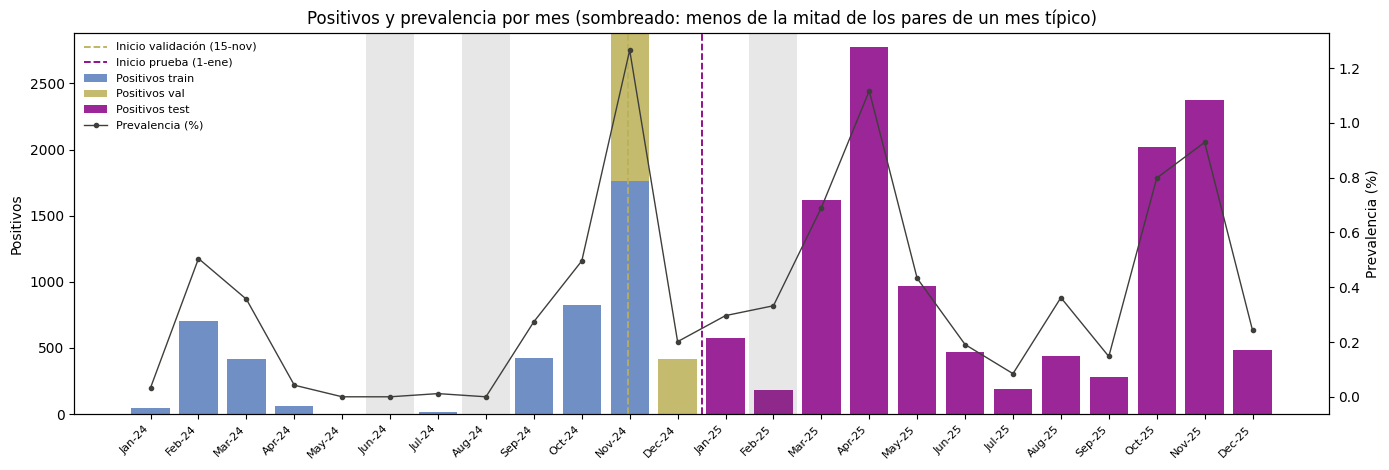

          pares  positivos prevalencia  cobertura_baja
2024-01  128635         43      0.033%           False
2024-02  139908        706      0.505%           False
2024-03  117639        419      0.356%           False
2024-04  146295         62      0.042%           False
2024-05   92731          0      0.000%           False
2024-06    2006          0      0.000%            True
2024-07  111508         13      0.012%           False
2024-08   82176          0      0.000%            True
2024-09  155408        426      0.274%           False
2024-10  166532        826      0.496%           False
2024-11  227775       2882      1.265%           False
2024-12  208620        420      0.201%           False
2025-01  193677        574      0.296%           False
2025-02   54168        180      0.332%            True
2025-03  234747       1620      0.690%           False
2025-04  248296       2773      1.117%           False
2025-05  224054        969      0.432%           False
2025-06  2

In [4]:
# ============================================================
# Sección 1 — Ciclo estacional
# ============================================================
MESES = pd.period_range("2024-01", "2025-12", freq="M")
mens = uso.groupby("mes")["etiqueta"].agg(pares="size", positivos="sum").reindex(MESES, fill_value=0)
mens["prevalencia"] = mens["positivos"] / mens["pares"].replace(0, np.nan)
mens["cobertura_baja"] = mens["pares"] < 0.5 * mens["pares"].median()
pos_mp = (uso.groupby(["mes", "periodo"])["etiqueta"].sum().unstack("periodo")
             .reindex(index=MESES, columns=ORDEN).fillna(0))

x = np.arange(len(MESES))
fig, ax = plt.subplots(figsize=(14, 4.8))
abajo = np.zeros(len(MESES))
for p in ORDEN:
    ax.bar(x, pos_mp[p], bottom=abajo, color=COL_PER[p], alpha=0.85, width=0.8, label=f"Positivos {p}")
    abajo += pos_mp[p].to_numpy()
for i in np.flatnonzero(mens["cobertura_baja"]):
    ax.axvspan(i - 0.5, i + 0.5, color=ROL["linea_ref"], alpha=0.12, lw=0)
i_nov = MESES.get_loc(pd.Period("2024-11", "M"))
ax.axvline(i_nov - 0.5 + 14 / 30, color=ROL["corte_val"], ls="--", lw=1.3, label="Inicio validación (15-nov)")
ax.axvline(MESES.get_loc(pd.Period("2025-01", "M")) - 0.5, color=ROL["corte_test"], ls="--", lw=1.3,
           label="Inicio prueba (1-ene)")
ax.set_ylabel("Positivos")
ax.set_xticks(x)
ax.set_xticklabels([m.strftime("%b-%y") for m in MESES], rotation=45, ha="right", fontsize=8)

ax_r = ax.twinx()
ax_r.plot(x, mens["prevalencia"] * 100, "o-", ms=3, lw=1, color=ROL["linea_ref"], label="Prevalencia (%)")
ax_r.set_ylabel("Prevalencia (%)")
ax_r.grid(False)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left", frameon=False)
ax.set_title("Positivos y prevalencia por mes (sombreado: menos de la mitad de los pares de un mes típico)")
plt.tight_layout()
fig.savefig("img-eda-ciclo_estacional.png", dpi=200, bbox_inches="tight")
plt.show()

print(mens.assign(prevalencia=lambda d: d["prevalencia"].map("{:.3%}".format)).to_string())

# Concentración de los positivos de entrenamiento en noviembre de 2024
pos_tr = uso[(uso["periodo"] == "train") & (uso["etiqueta"] == 1)]
nov_tr = (pos_tr["mes"] == pd.Period("2024-11", "M")).sum()
print(f"\nEntrenamiento: {nov_tr:,} de {len(pos_tr):,} positivos ({nov_tr / len(pos_tr):.1%}) "
      f"en la primera quincena de noviembre de 2024")

**Resultado — ciclo estacional.** La distribución mensual refleja las dos temporadas de lluvia de la Sabana, de febrero a mayo y de octubre a noviembre (Casallas-García et al., 2023), pero estas no están representadas por igual en los tres períodos. En 2025, la primera temporada es la más activa del registro: de febrero a mayo se reúne el 44.8% de los positivos de prueba, con una prevalencia de 1.117% en abril, y octubre y noviembre aportan el 35.5%. En 2024, en cambio, la primera temporada se concentra en febrero y marzo y se interrumpe después: abril registra una prevalencia de 0.042% y mayo no tiene positivos. Así, de febrero a mayo se reúne el 27.9% de los positivos de entrenamiento, mientras que octubre y la primera quincena de noviembre aportan el 60.8%; esa quincena reúne por sí sola 1,760 positivos, el 41.4% del total. La validación hereda la misma concentración, puesto que la segunda quincena de noviembre aporta el 72.8% de sus positivos. El modelo se entrena, por tanto, sobre todo con episodios del final de la segunda temporada de un año poco lluvioso, y se evalúa sobre un año en que la primera temporada es la dominante.

Tres meses tienen menos de la mitad de los pares de un mes típico: junio y agosto de 2024 y febrero de 2025. En junio de 2024, con 2,006 pares, la ausencia de positivos no puede distinguirse de la falta de datos. En agosto de 2024, en cambio, los 82,176 pares sin ningún positivo, al igual que los 92,731 de mayo, indican meses efectivamente secos y no un efecto de la cobertura.

         posibles  definidos  utilizables  en_uso  est_con_etiq  %_definidos  %_excluidos  %_sin_imagen
2024-01    281232     131260       131208  128635            52         46.7          0.0           2.0
2024-02    263088     141856       141000  139908            52         53.9          0.6           0.8
2024-03    281232     119012       118375  117639            52         42.3          0.5           0.6
2024-04    272160     147071       146993  146295            52         54.0          0.1           0.5
2024-05    281232      93763        93763   92731            52         33.3          0.0           1.1
2024-06    272160       2008         2008    2006            43          0.7          0.0           0.1
2024-07    281232     112026       112000  111508            51         39.8          0.0           0.4
2024-08    281232      82243        82243   82176            51         29.2          0.0           0.1
2024-09    272160     160178       159658  155408            58 

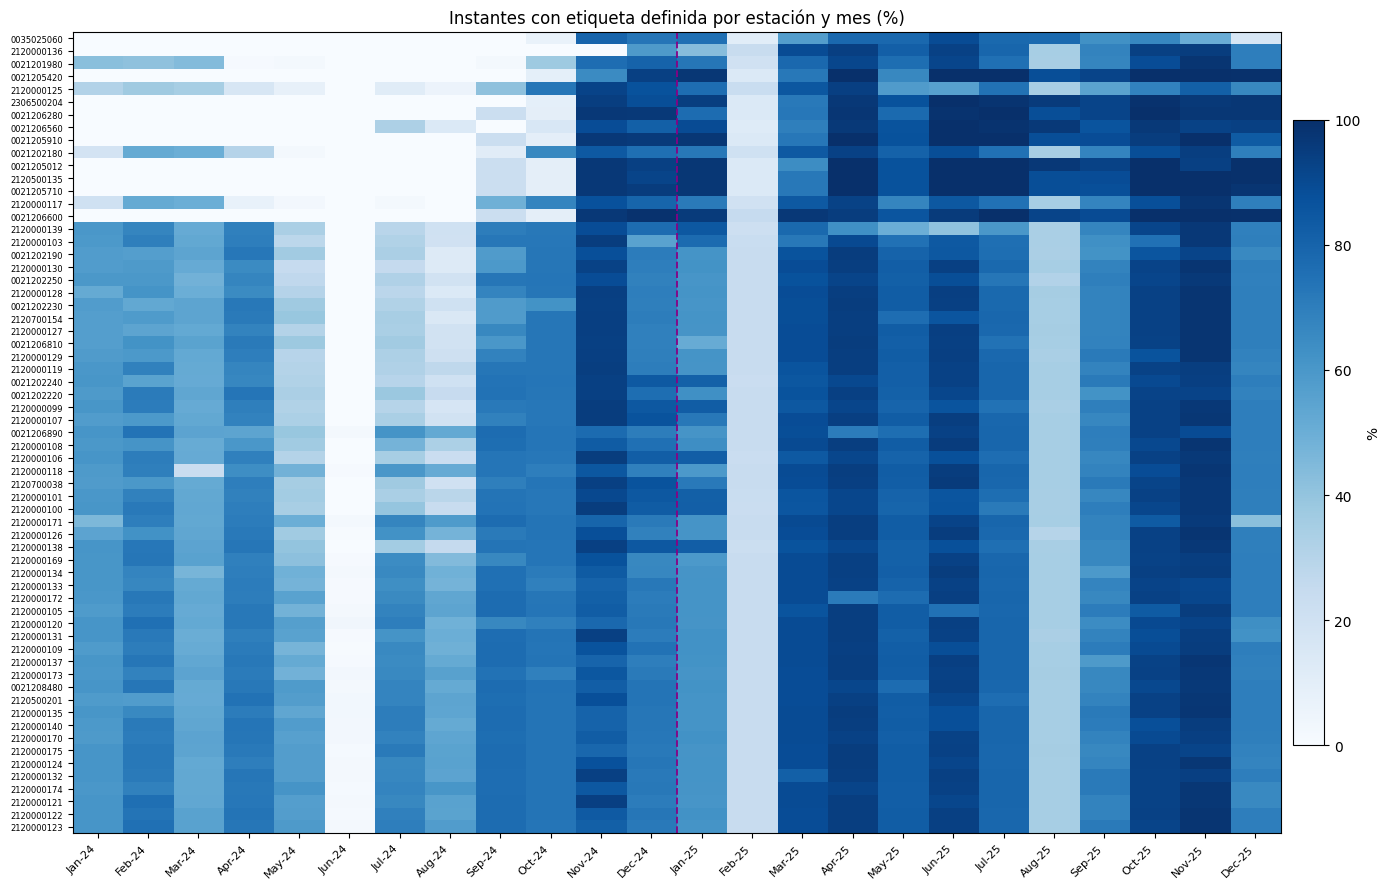


Estaciones con cobertura media < 50%: 2024 = 16, 2025 = 0


In [ ]:
# ============================================================
# Sección 1 — Cobertura de pares por mes: etiquetas frente a imágenes
# ============================================================
etiq = pd.read_parquet(RUTA_GT / "etiquetas_ground_truth.parquet",
                       columns=["codigoestacion", "timestamp", "etiqueta", "en_curso", "inminente"])
assert str(etiq["timestamp"].dt.tz) == "UTC"
etiq["mes"] = etiq["timestamp"].dt.tz_convert(TZ).dt.tz_localize(None).dt.to_period("M")
definida = etiq["etiqueta"].notna()
util     = definida & ~etiq["en_curso"] & ~etiq["inminente"]

n_est = len(umbrales)
cob = pd.DataFrame({
    "posibles":     n_est * 144 * MESES.days_in_month,
    "definidos":    etiq[definida].groupby("mes").size(),
    "utilizables":  etiq[util].groupby("mes").size(),
    "en_uso":       mens["pares"],
    "est_con_etiq": etiq[definida].groupby("mes")["codigoestacion"].nunique(),
}, index=MESES).fillna(0).astype(int)
cob["%_definidos"]    = cob["definidos"] / cob["posibles"] * 100            # cobertura de las estaciones
cob["%_excluidos"]    = (1 - cob["utilizables"] / cob["definidos"]) * 100   # lluvia en curso o tormenta inminente
cob["%_sin_imagen"]   = (1 - cob["en_uso"] / cob["utilizables"]) * 100      # historia insuficiente y purga
print(cob.round(1).to_string())

anual = cob.groupby(cob.index.year)[["posibles", "definidos", "utilizables", "en_uso"]].sum()
anual["%_definidos"]  = anual["definidos"] / anual["posibles"] * 100
anual["%_sin_imagen"] = (1 - anual["en_uso"] / anual["utilizables"]) * 100
print("\nPor año:")
print(anual.round(1).to_string())

# Fracción de instantes con etiqueta definida por estación y mes
cob_est = (etiq[definida].groupby(["codigoestacion", "mes"]).size().unstack()
           .reindex(index=umbrales.index, columns=MESES).fillna(0)
           / (144 * MESES.days_in_month.to_numpy()))
cob_est = cob_est.loc[cob_est.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(cob_est.to_numpy() * 100, aspect="auto", cmap="Blues", vmin=0, vmax=100, interpolation="nearest")
ax.set_xticks(np.arange(len(MESES)))
ax.set_xticklabels([m.strftime("%b-%y") for m in MESES], rotation=45, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(cob_est)))
ax.set_yticklabels(cob_est.index, fontsize=6)
ax.axvline(MESES.get_loc(pd.Period("2025-01", "M")) - 0.5, color=ROL["corte_test"], ls="--", lw=1.3)
ax.set_title("Instantes con etiqueta definida por estación y mes (%)")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="%")
plt.tight_layout()
plt.show()

print(f"\nEstaciones con cobertura media < 50%: 2024 = "
      f"{(cob_est.loc[:, cob_est.columns.year == 2024].mean(axis=1) < 0.5).sum()}, "
      f"2025 = {(cob_est.loc[:, cob_est.columns.year == 2025].mean(axis=1) < 0.5).sum()}")

**Cobertura.** La diferencia en el número de pares entre los dos años se debe a la cobertura de las estaciones y no a la de las imágenes. En 2024 tiene etiqueta definida el 48.5% de los instantes posibles, que resultan de las 63 estaciones cada diez minutos, frente al 74.7% en 2025. La falta de imagen o de historia, en cambio, descarta a lo sumo el 3.1% de los pares utilizables de cada mes, y el 1.5% y el 0.7% en el conjunto de cada año.

La menor cobertura de 2024 tiene dos componentes. Por un lado, entre enero y mayo, 11 de las 63 estaciones no tienen ninguna etiqueta definida, y la red solo las reúne todas en diciembre, tras pasar a 58 estaciones en septiembre y a 62 en octubre y noviembre. Por otro, las estaciones con registro durante todo el año presentan en 2024 una cobertura sensiblemente menor que en 2025. A esto se suman caídas que afectan simultáneamente a toda la red, en junio de 2024 (0.7%), agosto de 2024 (29.2%), febrero de 2025 (22.1%) y agosto de 2025 (43.2%), lo que indica interrupciones de la transmisión y no fallas de estaciones individuales.

La cobertura condiciona la lectura de los conteos de positivos, pero no la de la prevalencia, que se calcula sobre los pares disponibles. La concentración de los positivos de entrenamiento en la primera quincena de noviembre responde en parte a que noviembre es el mes de 2024 con mayor cobertura (86.8%, frente a valores entre 29% y 61% de enero a octubre, sin contar junio). Con todo, su prevalencia (1.265%) es también la más alta del año, de modo que la concentración no es solo un efecto del registro. En las estaciones que se incorporan tarde, además, el entrenamiento contiene casi exclusivamente episodios de la segunda temporada de lluvias. Las dos estaciones sin positivos en entrenamiento identificadas en `11-dataset_training.ipynb`, 2120000136 y 0021205420, pertenecen a este grupo, de modo que la ausencia de positivos refleja la falta de registro y no de eventos.

In [7]:
# Cifras citadas en el texto de la Sección 1
assert resumen_h["hora_pico"].tolist() == [13, 13, 12]
assert resumen_h.loc["train", "%_en_pico"] == 14.9
assert resumen_h["%_entre_10_y_15h"].tolist() == [63.0, 39.9, 46.6]
assert resumen_h["%_entre_19_y_06h"].tolist() == [17.5, 42.4, 32.1]

def pct(periodo, meses):
    sel = [pd.Period(m, "M") for m in meses]
    return round(pos_mp.loc[sel, periodo].sum() / pos_mp[periodo].sum() * 100, 1)

assert pct("train", ["2024-02", "2024-03", "2024-04", "2024-05"]) == 27.9
assert pct("train", ["2024-10", "2024-11"]) == 60.8
assert pct("test", ["2025-02", "2025-03", "2025-04", "2025-05"]) == 44.8
assert pct("test", ["2025-10", "2025-11"]) == 35.5
assert pct("val", ["2024-11"]) == 72.8
assert (nov_tr, f"{nov_tr / len(pos_tr):.1%}") == (1760, "41.4%")
assert mens["cobertura_baja"].sum() == 3
assert mens.loc[[pd.Period(m, "M") for m in ["2024-06", "2024-08", "2025-02"]], "cobertura_baja"].all()

anio24 = [pd.Period(f"2024-{m:02d}", "M") for m in range(1, 13)]
assert anual["%_definidos"].round(1).tolist() == [48.5, 74.7]
assert anual["%_sin_imagen"].round(1).tolist() == [1.5, 0.7]
assert round(cob["%_sin_imagen"].max(), 1) == 3.1
assert (cob.loc[anio24[:5], "est_con_etiq"] == 52).all()
assert cob.loc[[pd.Period(m, "M") for m in ["2024-09", "2024-10", "2024-11", "2024-12"]], "est_con_etiq"].tolist() == [58, 62, 62, 63]
assert cob.loc[[pd.Period(m, "M") for m in ["2024-06", "2024-08", "2025-02", "2025-08", "2024-11"]],
               "%_definidos"].round(1).tolist() == [0.7, 29.2, 22.1, 43.2, 86.8]
ene_oct = [m for m in anio24[:10] if m != pd.Period("2024-06", "M")]
assert (round(cob.loc[ene_oct, "%_definidos"].min()), round(cob.loc[ene_oct, "%_definidos"].max())) == (29, 61)
assert mens.loc[anio24, "prevalencia"].idxmax() == pd.Period("2024-11", "M")
tardias = cob_est.index[cob_est[anio24[:5]].sum(axis=1) == 0]
assert len(tardias) == 11 and {"2120000136", "0021205420"} <= set(tardias)
print("Cifras de la Sección 1 verificadas")

Cifras de la Sección 1 verificadas


## Sección 2 — Heterogeneidad entre estaciones

El umbral de cada estación es su propio percentil 95 de las horas húmedas, de modo que, si la frecuencia de lluvia fuerte fuera homogénea en la Sabana, todas las estaciones tendrían una tasa de positivos parecida. Las diferencias entre estaciones reflejan entonces la variación espacial de la frecuencia de horas húmedas, la cobertura de cada registro y, en las estaciones con umbral de respaldo o de excepción, el efecto de no usar un umbral propio. Esta sección cuantifica esa heterogeneidad, su relación con el umbral y su estabilidad entre 2024 y 2025, que indica si la tasa de cada estación responde a una climatología propia o a los episodios de un año particular. También identifica las estaciones con pocos positivos en validación y prueba, cuya destreza individual no podrá estimarse.

La comparación entre años distingue las estaciones que se incorporan a la red durante 2024 (Sección 1), cuya tasa de ese año proviene casi exclusivamente de meses lluviosos y no es, por tanto, comparable con la de 2025.

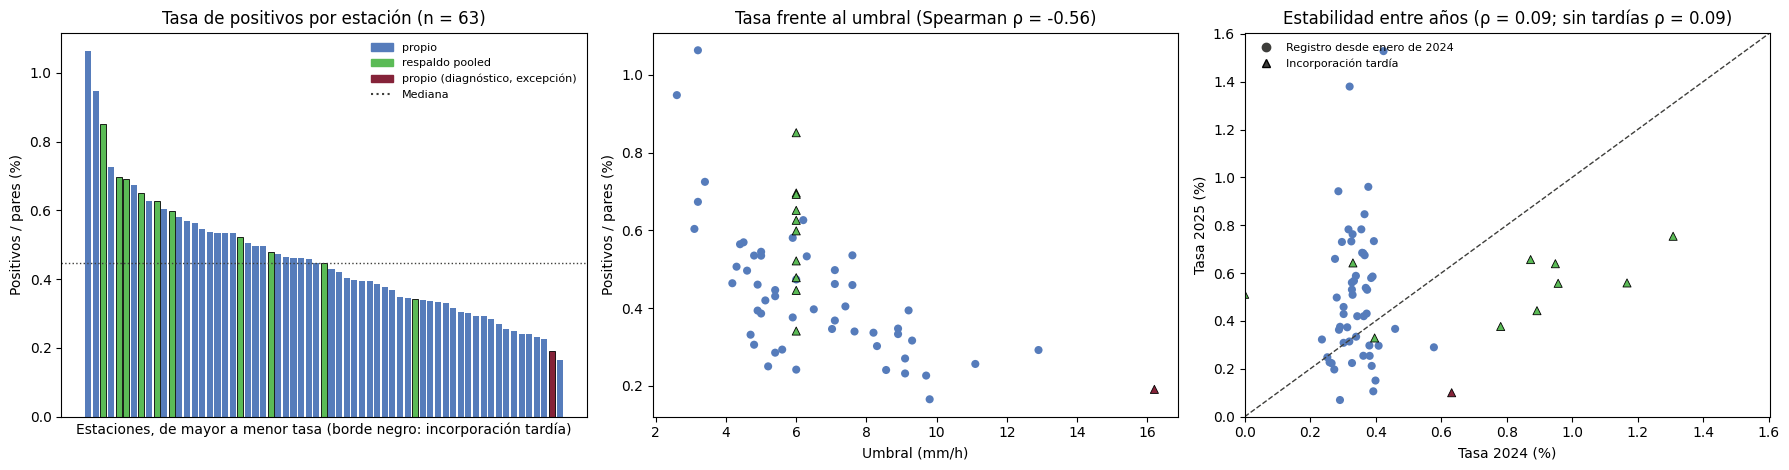

Tasa por estación: mediana 0.446%, rango 0.166% – 1.064% (cociente máx/mín 6.4)
Spearman tasa–umbral        : ρ = -0.56 (p = 1.7e-06)
Spearman 2024–2025 (todas)  : ρ = 0.09 (p = 4.7e-01, n = 63)
Spearman 2024–2025 (sin tardías): ρ = 0.09 (p = 5.5e-01, n = 52)
Las 10 estaciones con más positivos reúnen el 25.6% del total

Mediana de la tasa por grupo de registro (%):
                       tasa  tasa_2024  tasa_2025
tardia                                           
desde enero de 2024   0.401      0.337      0.445
incorporación tardía  0.599      0.873      0.557

Origen del umbral según el grupo de registro:
tardia                           desde enero de 2024  tardía
origen                                                      
propio                                            52       0
propio (diagnóstico, excepción)                    0       1
respaldo pooled                                    0      10

Tasa por origen del umbral (%):
                                 count    min 

In [8]:
# ============================================================
# Sección 2 — Tasa de positivos por estación
# ============================================================
por_est = uso.groupby("codigoestacion")["etiqueta"].agg(pares="size", positivos="sum")
por_est["tasa"] = por_est["positivos"] / por_est["pares"]
anual = uso.groupby(["codigoestacion", uso["t_local"].dt.year])["etiqueta"].mean().unstack()
por_est = (por_est.join(anual.add_prefix("tasa_"))
                  .join(umbrales[["umbral_mm_h", "origen"]])
                  .sort_values("tasa", ascending=False))
pos_per = uso.groupby(["codigoestacion", "periodo"])["etiqueta"].sum().unstack().reindex(columns=ORDEN).fillna(0)
por_est = por_est.join(pos_per.add_prefix("pos_"))
por_est["tardia"] = por_est.index.isin(tardias)        # sin etiquetas entre enero y mayo de 2024 (Sección 1)
assert por_est["umbral_mm_h"].notna().all(), "estaciones sin umbral"
assert por_est["tardia"].sum() == len(tardias)

ORIGENES = list(por_est["origen"].value_counts().index)
COL_ORIG = dict(zip(ORIGENES, [ROL["serie"], ROL["estacional"], ROL["positivo"], ROL["linea_ref"]]))
col_est  = por_est["origen"].map(COL_ORIG)
MARCA    = {False: "o", True: "^"}

rho_umb, p_umb = stats.spearmanr(por_est["umbral_mm_h"], por_est["tasa"])
d_an = por_est.dropna(subset=["tasa_2024", "tasa_2025"])
rho_an, p_an   = stats.spearmanr(d_an["tasa_2024"], d_an["tasa_2025"])
d_cc = d_an[~d_an["tardia"]]
rho_cc, p_cc   = stats.spearmanr(d_cc["tasa_2024"], d_cc["tasa_2025"])

def dispersion(ax, d, x, y):
    for tard in (False, True):
        s = d[d["tardia"] == tard]
        ax.scatter(s[x] * (100 if x.startswith("tasa") else 1), s[y] * 100, c=col_est.loc[s.index],
                   marker=MARCA[tard], s=34, edgecolors="black" if tard else "none", linewidths=0.6)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
ax = axes[0]
ax.bar(range(len(por_est)), por_est["tasa"] * 100, color=col_est,
       edgecolor=np.where(por_est["tardia"], "black", "none"), linewidth=0.6)
ax.axhline(por_est["tasa"].median() * 100, color=ROL["linea_ref"], ls=":", lw=1)
ax.set_xticks([]); ax.set_xlabel("Estaciones, de mayor a menor tasa (borde negro: incorporación tardía)")
ax.set_ylabel("Positivos / pares (%)"); ax.set_title(f"Tasa de positivos por estación (n = {len(por_est)})")
ax.legend(handles=[Patch(color=c, label=k) for k, c in COL_ORIG.items()]
          + [plt.Line2D([], [], color=ROL["linea_ref"], ls=":", label="Mediana")], fontsize=8, frameon=False)

ax = axes[1]
dispersion(ax, por_est, "umbral_mm_h", "tasa")
ax.set_xlabel("Umbral (mm/h)"); ax.set_ylabel("Positivos / pares (%)")
ax.set_title(f"Tasa frente al umbral (Spearman ρ = {rho_umb:.2f})")

ax = axes[2]
lim = max(d_an[["tasa_2024", "tasa_2025"]].max().max() * 100 * 1.05, 0.1)
ax.plot([0, lim], [0, lim], color=ROL["linea_ref"], ls="--", lw=1)
dispersion(ax, d_an, "tasa_2024", "tasa_2025")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Tasa 2024 (%)"); ax.set_ylabel("Tasa 2025 (%)")
ax.set_title(f"Estabilidad entre años (ρ = {rho_an:.2f}; sin tardías ρ = {rho_cc:.2f})")
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=ROL["linea_ref"], label="Registro desde enero de 2024"),
                   plt.Line2D([], [], marker="^", ls="", color=ROL["linea_ref"], markeredgecolor="black",
                              label="Incorporación tardía")], fontsize=8, frameon=False, loc="upper left")
plt.tight_layout()
#fig.savefig("img-eda-estaciones.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Tasa por estación: mediana {por_est['tasa'].median():.3%}, "
      f"rango {por_est['tasa'].min():.3%} – {por_est['tasa'].max():.3%} "
      f"(cociente máx/mín {por_est['tasa'].max() / por_est['tasa'].min():.1f})")
print(f"Spearman tasa–umbral        : ρ = {rho_umb:.2f} (p = {p_umb:.1e})")
print(f"Spearman 2024–2025 (todas)  : ρ = {rho_an:.2f} (p = {p_an:.1e}, n = {len(d_an)})")
print(f"Spearman 2024–2025 (sin tardías): ρ = {rho_cc:.2f} (p = {p_cc:.1e}, n = {len(d_cc)})")
top10 = por_est["positivos"].nlargest(10).sum() / por_est["positivos"].sum()
print(f"Las 10 estaciones con más positivos reúnen el {top10:.1%} del total\n")

print("Mediana de la tasa por grupo de registro (%):")
print((por_est.groupby("tardia")[["tasa", "tasa_2024", "tasa_2025"]].median() * 100)
      .rename(index={False: "desde enero de 2024", True: "incorporación tardía"}).round(3).to_string())
print("\nOrigen del umbral según el grupo de registro:")
print(pd.crosstab(por_est["origen"], por_est["tardia"].map({False: "desde enero de 2024", True: "tardía"})).to_string())

print("\nTasa por origen del umbral (%):")
print((por_est.groupby("origen")["tasa"].describe()[["count", "min", "50%", "max"]] * [1, 100, 100, 100])
      .round(3).to_string())
print("\nEstaciones según positivos disponibles por período:")
print(pd.DataFrame({p: {"0 positivos": int((por_est[f"pos_{p}"] == 0).sum()),
                        "1–9": int(por_est[f"pos_{p}"].between(1, 9).sum()),
                        "10–49": int(por_est[f"pos_{p}"].between(10, 49).sum()),
                        "≥ 50": int((por_est[f"pos_{p}"] >= 50).sum())} for p in ORDEN}).to_string())
print("\nExtremos:")
cols = ["pares", "positivos", "tasa", "tasa_2024", "tasa_2025", "umbral_mm_h", "origen", "tardia"]
print(pd.concat([por_est.head(5), por_est.tail(5)])[cols]
      .assign(tasa=lambda d: d["tasa"].map("{:.3%}".format),
              tasa_2024=lambda d: d["tasa_2024"].map("{:.3%}".format),
              tasa_2025=lambda d: d["tasa_2025"].map("{:.3%}".format)).to_string())

In [9]:
# Relación tasa–umbral por año, solo estaciones con P95 propio (período de referencia del umbral: 2024)
prop = por_est[por_est["origen"] == "propio"].copy()
prop["razon_25_24"] = prop["tasa_2025"] / prop["tasa_2024"]
filas = {}
for col in ["tasa_2024", "tasa_2025", "tasa", "razon_25_24"]:
    r, p = stats.spearmanr(prop["umbral_mm_h"], prop[col])
    q10, q50, q90 = prop[col].quantile([0.1, 0.5, 0.9])
    esc = 1 if col == "razon_25_24" else 100
    filas[col] = {"rho_umbral": r, "p": p, "p10": q10 * esc, "mediana": q50 * esc, "p90": q90 * esc,
                  "p90/p10": q90 / q10}
print(f"Estaciones con umbral propio: {len(prop)}")
print(pd.DataFrame(filas).T.round(3).to_string())

Estaciones con umbral propio: 52
             rho_umbral      p    p10  mediana    p90  p90/p10
tasa_2024         0.201  0.152  0.276    0.337  0.394    1.427
tasa_2025        -0.708  0.000  0.224    0.445  0.783    3.500
tasa             -0.660  0.000  0.251    0.401  0.602    2.398
razon_25_24      -0.764  0.000  0.668    1.419  2.452    3.671


**Resultado.** La tasa de positivos varía entre estaciones de 0.166% a 1.064%, un factor de 6.4, con una mediana de 0.446%, y las diez estaciones con más positivos reúnen el 25.6% del total. Esta heterogeneidad no responde a una climatología propia de cada estación, sino a la combinación del umbral, calculado sobre el año 2024, con la diferencia entre los dos años del registro.

En las 52 estaciones con umbral propio, la tasa de 2024 es casi uniforme. Entre los percentiles 10 y 90 va de 0.276% a 0.394%, una razón de 1.4, y no se relaciona con el umbral (coeficiente de correlación de rangos de Spearman ρ = 0.20). Es lo esperable, puesto que en ese año cada estación se evalúa con un percentil de su propia distribución. En 2025, en cambio, la razón entre los percentiles 90 y 10 sube a 3.5, y la tasa se relaciona negativamente con el umbral (ρ = −0.71): las estaciones con umbral bajo lo superan con mucha más frecuencia que en el año de referencia. La razón entre las tasas de 2025 y 2024 tiene una mediana de 1.42, en coherencia con el carácter más lluvioso de 2025 descrito en la Sección 1. Sin embargo, varía de 0.67 a 2.45 entre los percentiles 10 y 90 y desciende con el umbral (ρ = −0.76). En consecuencia, el ordenamiento de las estaciones según su tasa no se conserva entre años (ρ = 0.09), tanto con las 63 estaciones como sin las que se incorporan tarde a la red. Los coeficientes se emplean como medida descriptiva de la asociación entre los ordenamientos de las estaciones y no se acompañan de una prueba de significación: las estaciones vecinas registran eventos de forma conjunta (`11-dataset_training.ipynb`), de modo que no constituyen observaciones independientes. Los datos disponibles no permiten determinar si la mayor respuesta de las estaciones de umbral bajo al año más lluvioso tiene un origen climático o instrumental.

Para la evaluación, esto implica que la prevalencia del conjunto de prueba es heterogénea entre estaciones y que las métricas agregadas pesan más a las estaciones de umbral bajo. El umbral se fija con el período de entrenamiento y se aplica sin modificación a 2025, como corresponde a una evaluación que no usa información del futuro. La consecuencia es que, en 2025, superar el umbral no representa el mismo grado de excepcionalidad en todas las estaciones.

Las 11 estaciones sin percentil propio, que no tienen registro entre marzo y mayo de 2024 (`04-ground_truth_threshold.ipynb`), son las mismas que se incorporan tarde a la red (Sección 1). Diez de ellas usan el umbral de respaldo de 6 mm/h, y Nueva Generación (`0021206600`) su umbral de excepción de 16.2 mm/h. Su tasa de 2024 proviene casi exclusivamente de los meses lluviosos del segundo semestre, de modo que su mediana en ese año (0.873%) supera tanto la de las estaciones con registro completo (0.337%) como su propia mediana de 2025 (0.557%).

Por último, el número de positivos por estación condiciona el nivel al que puede evaluarse el modelo. En entrenamiento, 48 estaciones reúnen al menos 50 positivos, y las dos que no tienen ninguno pertenecen al grupo de incorporación tardía. En validación, solo 3 estaciones alcanzan 50 positivos, 52 tienen entre 10 y 49 y 5 no tienen ninguno, de modo que la validación permite evaluar el modelo en conjunto pero no por estación. En prueba, en cambio, 60 de las 63 estaciones reúnen al menos 50 positivos, lo que hace posible el análisis por estación.

In [11]:
# Cifras citadas en el texto de la Sección 2
assert (round(por_est["tasa"].min() * 100, 3), round(por_est["tasa"].max() * 100, 3),
        round(por_est["tasa"].median() * 100, 3)) == (0.166, 1.064, 0.446)
assert round(top10 * 100, 1) == 25.6
assert (round(rho_umb, 2), round(rho_an, 2), round(rho_cc, 2)) == (-0.56, 0.09, 0.09)
tab = pd.DataFrame(filas).T
assert tab["rho_umbral"].round(2).tolist() == [0.20, -0.71, -0.66, -0.76]
assert tab.loc["tasa_2024", ["p10", "p90"]].round(3).tolist() == [0.276, 0.394]
assert tab["p90/p10"].round(1).tolist()[:2] == [1.4, 3.5]
assert tab.loc["razon_25_24", ["p10", "mediana", "p90"]].round(2).tolist() == [0.67, 1.42, 2.45]
assert pd.crosstab(por_est["origen"], por_est["tardia"]).loc["propio", True] == 0
assert por_est.loc[por_est["tardia"], "origen"].value_counts().to_dict() == {"respaldo pooled": 10, "propio (diagnóstico, excepción)": 1}
med = por_est.groupby("tardia")[["tasa_2024", "tasa_2025"]].median() * 100
assert med.round(3).values.tolist() == [[0.337, 0.445], [0.873, 0.557]]
assert set(por_est.index[por_est["pos_train"] == 0]) <= set(tardias)
cnt = lambda p: [int((por_est[f"pos_{p}"] >= 50).sum()), int(por_est[f"pos_{p}"].between(10, 49).sum()),
                 int((por_est[f"pos_{p}"] == 0).sum())]
assert cnt("train")[0] == 48 and cnt("val") == [3, 52, 5] and cnt("test")[0] == 60
print("Cifras de la Sección 2 verificadas")

Cifras de la Sección 2 verificadas


## Sección 3 — Episodios independientes

Los positivos no son observaciones independientes. Una misma hora de lluvia fuerte vuelve positivas las seis imágenes de la hora en que su ventana la alcanza, y una tormenta que afecta a varias estaciones produce positivos simultáneos en todas ellas. El número de positivos sobreestima así la cantidad de situaciones meteorológicas distintas de que dispone cada período, que es lo que determina tanto la diversidad del entrenamiento como la precisión con que pueden estimarse las métricas en validación y prueba.

Los positivos se agrupan en dos niveles. Un episodio por estación es una secuencia de positivos consecutivos de la misma estación, en la que se toleran huecos de hasta 30 minutos, que corresponden a pares fuera del conjunto por falta de imagen o por exclusión. Un episodio regional reúne los episodios por estación cuyos intervalos se solapan en el tiempo, de modo que representa una misma situación convectiva sobre la red. Este criterio puede encadenar celdas distintas que se suceden durante una tarde, por lo que se complementa con el conteo de días con positivos y de días regionales (con positivos en al menos cinco estaciones), el criterio de la comparación de cortes de `11-dataset_training.ipynb`.

In [12]:
# ============================================================
# Sección 3 — Episodios por estación y regionales
# ============================================================
GAP = pd.Timedelta("30min")              # hueco tolerado dentro de un episodio por estación

pos_u = (uso[uso["etiqueta"] == 1]
         .sort_values(["codigoestacion", "timestamp"]).reset_index(drop=True))
nuevo = ((pos_u["codigoestacion"] != pos_u["codigoestacion"].shift())
         | (pos_u["periodo"] != pos_u["periodo"].shift())
         | (pos_u["timestamp"].diff() > GAP))
pos_u["ep_est"] = nuevo.cumsum()

ep = (pos_u.groupby("ep_est")
           .agg(codigoestacion=("codigoestacion", "first"), periodo=("periodo", "first"),
                t_ini=("timestamp", "min"), t_fin=("timestamp", "max"), n_pos=("etiqueta", "size"))
           .sort_values("t_ini").reset_index(drop=True))
ep["dur_h"] = (ep["t_fin"] - ep["t_ini"] + paso) / pd.Timedelta(hours=1)

# Episodios regionales: episodios por estación que se solapan en el tiempo (los períodos no se solapan)
ep["ep_reg"] = (ep["t_ini"] > ep["t_fin"].cummax().shift()).cumsum()
reg = (ep.groupby("ep_reg")
         .agg(periodo=("periodo", "first"), t_ini=("t_ini", "min"), t_fin=("t_fin", "max"),
              n_estaciones=("codigoestacion", "nunique"), n_pos=("n_pos", "sum")))
reg["dur_h"] = (reg["t_fin"] - reg["t_ini"] + paso) / pd.Timedelta(hours=1)
reg["mes"]   = reg["t_ini"].dt.tz_convert(TZ).dt.tz_localize(None).dt.to_period("M")
assert (ep.groupby("ep_reg")["periodo"].nunique() == 1).all(), "episodio regional que cruza períodos"

est_dia = pos_u.groupby(["periodo", "dia"])["codigoestacion"].nunique()
resumen_ep = pd.DataFrame({
    "positivos":            pos_u.groupby("periodo").size(),
    "ep_estacion":          ep.groupby("periodo").size(),
    "ep_regionales":        reg.groupby("periodo").size(),
    "dias_con_positivos":   est_dia.groupby("periodo").size(),
    "dias_regionales":      (est_dia >= MIN_EST).groupby("periodo").sum(),
    "pos_por_ep_est (med)": ep.groupby("periodo")["n_pos"].median(),
    "dur_ep_est_h (med)":   ep.groupby("periodo")["dur_h"].median(),
    "est_por_ep_reg (med)": reg.groupby("periodo")["n_estaciones"].median(),
    "est_por_ep_reg (máx)": reg.groupby("periodo")["n_estaciones"].max(),
}).reindex(ORDEN)
print(resumen_ep.to_string())

# Concentración de entrenamiento en noviembre de 2024, medida en episodios y en días
reg_tr = reg[reg["periodo"] == "train"]
dias_tr = est_dia.loc["train"]
nov = pd.Period("2024-11", "M")
print(f"\nEntrenamiento, noviembre de 2024: {(reg_tr['mes'] == nov).sum()} de {len(reg_tr)} episodios regionales "
      f"({(reg_tr['mes'] == nov).mean():.1%}); "
      f"{sum(pd.Period(d, 'M') == nov for d in dias_tr.index)} de {len(dias_tr)} días con positivos")

print("\nEpisodios regionales más extensos:")
print(reg.sort_values("n_estaciones", ascending=False).head(8)
         .assign(t_ini=lambda d: d["t_ini"].dt.tz_convert(TZ).dt.strftime("%Y-%m-%d %H:%M"),
                 t_fin=lambda d: d["t_fin"].dt.tz_convert(TZ).dt.strftime("%Y-%m-%d %H:%M"))
         [["periodo", "t_ini", "t_fin", "dur_h", "n_estaciones", "n_pos"]].round(1).to_string())

         positivos  ep_estacion  ep_regionales  dias_con_positivos  dias_regionales  pos_por_ep_est (med)  dur_ep_est_h (med)  est_por_ep_reg (med)  est_por_ep_reg (máx)
periodo                                                                                                                                                                  
train         4255          428             78                  49               26                  10.0            1.666667                   3.0                    30
val           1542          159             48                  25               10                  10.0            1.666667                   1.0                    21
test         12367         1127            272                 158               69                  11.0            1.833333                   2.0                    45

Entrenamiento, noviembre de 2024: 31 de 78 episodios regionales (39.7%); 13 de 49 días con positivos

Episodios regionales más extensos:
       perio

In [13]:
# Cifras que deben coincidir con la comparación de cortes de 11-dataset_training.ipynb
assert resumen_ep.loc["train", "positivos"] == 4255 and resumen_ep.loc["val", "positivos"] == 1542
assert resumen_ep.loc["train", "dias_regionales"] == 26
assert (resumen_ep.loc["val", "dias_con_positivos"], resumen_ep.loc["val", "dias_regionales"]) == (25, 10)
print("Coincidencia con 11-dataset_training verificada")

Coincidencia con 11-dataset_training verificada


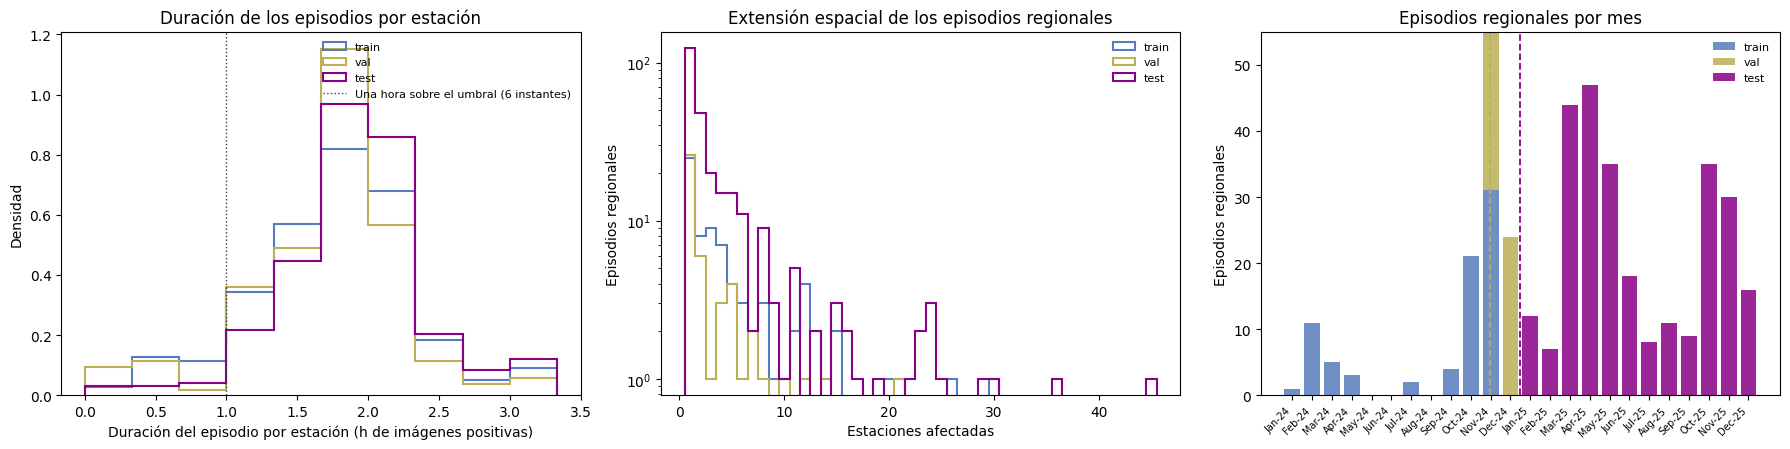

Episodios por estación de menos de una hora: 5.1%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

ax = axes[0]
bins = np.arange(0, ep["dur_h"].max() + 0.5, 1 / 3)
for p in ORDEN:
    ax.hist(ep.loc[ep["periodo"] == p, "dur_h"], bins=bins, density=True, histtype="step",
            lw=1.5, color=COL_PER[p], label=p)
ax.axvline(1, color=ROL["linea_ref"], ls=":", lw=1, label="Una hora sobre el umbral (6 instantes)")
ax.set_xlabel("Duración del episodio por estación (h de imágenes positivas)")
ax.set_ylabel("Densidad"); ax.set_title("Duración de los episodios por estación")
ax.legend(fontsize=8, frameon=False)

ax = axes[1]
bins = np.arange(1, reg["n_estaciones"].max() + 2)
for p in ORDEN:
    ax.hist(reg.loc[reg["periodo"] == p, "n_estaciones"], bins=bins, histtype="step",
            lw=1.5, color=COL_PER[p], label=p, align="left")
ax.set_yscale("log")
ax.set_xlabel("Estaciones afectadas"); ax.set_ylabel("Episodios regionales")
ax.set_title("Extensión espacial de los episodios regionales")
ax.legend(fontsize=8, frameon=False)

ax = axes[2]
reg_mes = reg.groupby(["mes", "periodo"]).size().unstack().reindex(index=MESES, columns=ORDEN).fillna(0)
abajo = np.zeros(len(MESES))
for p in ORDEN:
    ax.bar(np.arange(len(MESES)), reg_mes[p], bottom=abajo, color=COL_PER[p], alpha=0.85, label=p)
    abajo += reg_mes[p].to_numpy()
ax.axvline(i_nov - 0.5 + 14 / 30, color=ROL["corte_val"], ls="--", lw=1.3)
ax.axvline(MESES.get_loc(pd.Period("2025-01", "M")) - 0.5, color=ROL["corte_test"], ls="--", lw=1.3)
ax.set_xticks(np.arange(len(MESES)))
ax.set_xticklabels([m.strftime("%b-%y") for m in MESES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Episodios regionales"); ax.set_title("Episodios regionales por mes")
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
fig.savefig("img-eda-episodios.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Episodios por estación de menos de una hora: {(ep['dur_h'] < 1).mean():.1%}")

**Resultado.** Los positivos de cada período se reducen a un número mucho menor de situaciones meteorológicas distintas. En entrenamiento, los 4,255 positivos forman 428 episodios por estación, que se agrupan a su vez en 78 episodios regionales repartidos en 49 días. En validación, los 1,542 positivos corresponden a 159 episodios por estación, 48 regionales y 25 días, y en prueba, los 12,367 positivos, a 1,127 episodios por estación, 272 regionales y 158 días.

Un episodio por estación reúne una mediana de 10 a 11 positivos, algo menos de dos horas de imágenes, y en los tres períodos su duración se concentra entre una hora y media y dos horas y media. Cada instante en que la acumulación de la hora previa alcanza el umbral vuelve positivas seis imágenes consecutivas, de modo que un episodio completo dura al menos una hora. El 5.1% de los episodios por estación dura menos, fragmentados por pares que quedan fuera del conjunto.

La extensión espacial de los episodios es mayoritariamente local. La mediana de estaciones por episodio regional es de 3 en entrenamiento, 1 en validación y 2 en prueba, y en los tres períodos predominan los episodios de una sola estación. En el otro extremo, algunos episodios abarcan buena parte de la red: hasta 30 estaciones en entrenamiento (9 de noviembre de 2024) y 45 en prueba (13 de octubre de 2025). Los más extensos se prolongan entre tres y diez horas, lo que indica que el criterio de solapamiento temporal reúne en ellos varias celdas convectivas que se suceden durante una misma tarde. Por ello, el número de episodios regionales subestima el de sistemas independientes, y el conteo de días constituye una referencia complementaria más robusta.

La concentración del entrenamiento en noviembre de 2024 se mantiene al contar episodios: ese mes aporta 31 de los 78 episodios regionales (39.7%) y 13 de los 49 días con positivos, una proporción similar al 41.4% de los positivos. Noviembre no concentra los positivos por unas pocas tormentas extensas, sino por el número de episodios distintos, si bien la mayor cobertura de ese mes (Sección 1) contribuye a la cifra.

El tamaño efectivo de cada período está determinado por estos episodios y días, y no por el número de pares. Los pares de un mismo episodio comparten la escena y la lluvia, de modo que no aportan información independiente, y la incertidumbre de las métricas depende de la variabilidad entre días. La validación es el período más limitado, con 25 días con positivos, solo 10 de ellos regionales, y episodios mayoritariamente de una sola estación, por lo que las métricas calculadas sobre ella tendrán una variabilidad considerable. La prueba, con 158 días, ofrece una base más de seis veces mayor.

In [15]:
# Cifras citadas en el texto de la Sección 3
assert resumen_ep["ep_estacion"].tolist() == [428, 159, 1127]
assert resumen_ep["ep_regionales"].tolist() == [78, 48, 272]
assert resumen_ep["dias_con_positivos"].tolist() == [49, 25, 158]
assert resumen_ep["dias_regionales"].tolist() == [26, 10, 69]
assert resumen_ep["pos_por_ep_est (med)"].tolist() == [10, 10, 11]
assert resumen_ep["est_por_ep_reg (med)"].tolist() == [3, 1, 2]
assert resumen_ep["est_por_ep_reg (máx)"].tolist() == [30, 21, 45]
assert round((ep["dur_h"] < 1).mean() * 100, 1) == 5.1
assert ((reg_tr["mes"] == nov).sum(), sum(pd.Period(d, "M") == nov for d in dias_tr.index)) == (31, 13)
grandes = reg.sort_values("n_estaciones", ascending=False).head(8)
assert grandes["dur_h"].between(3, 10.5).all()
assert round(158 / 25, 1) == 6.3
print("Cifras de la Sección 3 verificadas")

Cifras de la Sección 3 verificadas


## Sección 4 — Negativos near-miss y aleatorios

`11-dataset_training.ipynb` divide los negativos de entrenamiento en dos grupos: los near-miss, tomados en instantes en que al menos otra estación de la red tiene etiqueta positiva, y los aleatorios, el resto. Esta sección describe en qué se diferencian ambos grupos respecto de los positivos en la hora del día, la época del año y la proximidad a eventos, para anticipar qué aporta cada uno al muestreo del entrenamiento. Un grupo aleatorio dominado por noches y meses secos ofrece al modelo ejemplos fáciles de separar, mientras que los near-miss deberían compartir con los positivos la hora y la época convectiva. La comparación se restringe a los pares de entrenamiento con la historia mínima ($L_{max} \geq 2$).

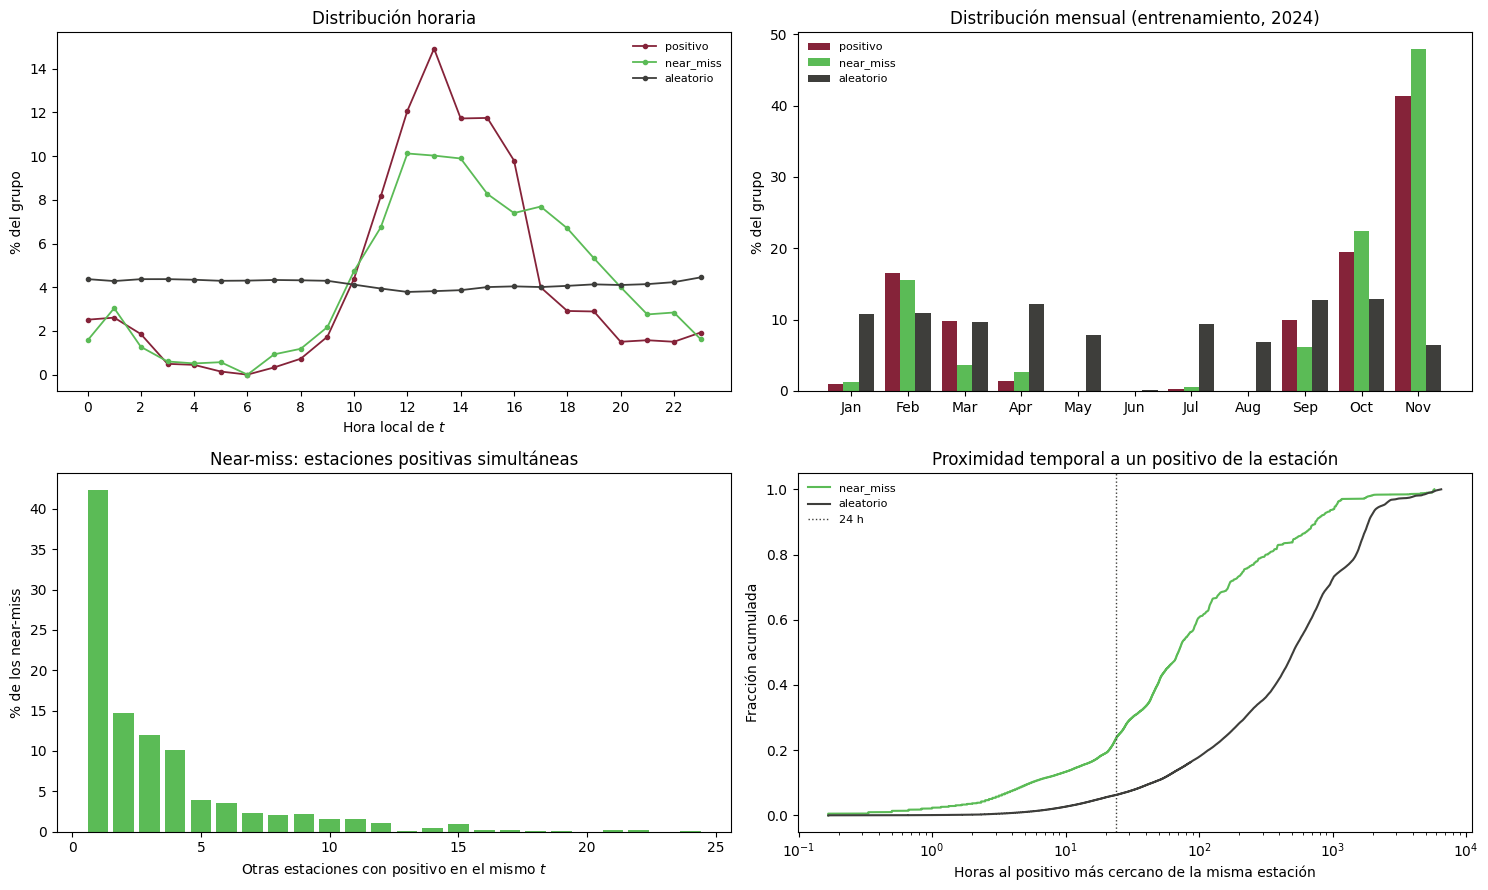

             pares  % entre 10 y 15 h  % entre 19 y 06 h  % en día con positivos  % en día regional  % a ≤ 24 h de un positivo  horas_a_positivo (med)
pool                                                                                                                                                  
positivo      4255               63.0               17.5                   100.0               88.9                        0.0                     NaN
near_miss    56788               49.8               24.1                   100.0               75.9                       23.7                    69.8
aleatorio  1186274               23.5               51.4                    23.6               12.3                        6.3                   506.0

Near-miss: mediana de 2 estaciones positivas simultáneas; 42.3% con una sola; distancia mediana a la positiva más cercana 11.3 km


In [16]:
# ============================================================
# Sección 4 — Grupos de negativos
# ============================================================
GRUPOS = ["positivo", "near_miss", "aleatorio"]
COL_GR = {"positivo": ROL["positivo"], "near_miss": ROL["estacional"], "aleatorio": ROL["linea_ref"]}

tr = uso[uso["periodo"] == "train"].copy()
assert tr["pool"].value_counts().reindex(GRUPOS).tolist() == [4255, 56788, 1186274]

# Días de entrenamiento con positivos y días regionales
dias_pos = est_dia.loc["train"]
tr["dia_con_pos"]  = tr["dia"].isin(dias_pos.index)
tr["dia_regional"] = tr["dia"].isin(dias_pos.index[dias_pos >= MIN_EST])

frac_hora = tr.groupby("pool")["hora"].value_counts(normalize=True).unstack(0).reindex(index=HORAS, columns=GRUPOS).fillna(0)
MESES_TR  = pd.period_range("2024-01", "2024-11", freq="M")
frac_mes  = tr.groupby("pool")["mes"].value_counts(normalize=True).unstack(0).reindex(index=MESES_TR, columns=GRUPOS).fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
ax = axes[0, 0]
for g in GRUPOS:
    ax.plot(frac_hora.index, frac_hora[g] * 100, "o-", ms=3, lw=1.3, color=COL_GR[g], label=g)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hora local de $t$"); ax.set_ylabel("% del grupo")
ax.set_title("Distribución horaria"); ax.legend(fontsize=8, frameon=False)

ax = axes[0, 1]
w = 0.27
for k, g in enumerate(GRUPOS):
    ax.bar(np.arange(len(MESES_TR)) + (k - 1) * w, frac_mes[g] * 100, width=w, color=COL_GR[g], label=g)
ax.set_xticks(np.arange(len(MESES_TR))); ax.set_xticklabels([m.strftime("%b") for m in MESES_TR])
ax.set_ylabel("% del grupo"); ax.set_title("Distribución mensual (entrenamiento, 2024)")
ax.legend(fontsize=8, frameon=False)

ax = axes[1, 0]
nm = tr[tr["pool"] == "near_miss"]
vc = nm["n_est_pos"].value_counts().sort_index()
ax.bar(vc.index, vc.values / vc.sum() * 100, color=COL_GR["near_miss"])
ax.set_xlabel("Otras estaciones con positivo en el mismo $t$"); ax.set_ylabel("% de los near-miss")
ax.set_title("Near-miss: estaciones positivas simultáneas")

ax = axes[1, 1]
for g in ["near_miss", "aleatorio"]:
    v = np.sort(tr.loc[tr["pool"] == g, "horas_a_positivo"].dropna().to_numpy())
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=COL_GR[g], lw=1.5, label=g)
ax.axvline(24, color=ROL["linea_ref"], ls=":", lw=1, label="24 h")
ax.set_xscale("log"); ax.set_xlabel("Horas al positivo más cercano de la misma estación")
ax.set_ylabel("Fracción acumulada"); ax.set_title("Proximidad temporal a un positivo de la estación")
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
fig.savefig("img-eda-negativos.png", dpi=200, bbox_inches="tight")
plt.show()

caract = pd.DataFrame({
    "pares":                 tr.groupby("pool").size(),
    "% entre 10 y 15 h":     tr.groupby("pool")["hora"].apply(lambda h: h.between(10, 15).mean() * 100),
    "% entre 19 y 06 h":     tr.groupby("pool")["hora"].apply(lambda h: ((h >= 19) | (h <= 6)).mean() * 100),
    "% en día con positivos": tr.groupby("pool")["dia_con_pos"].mean() * 100,
    "% en día regional":     tr.groupby("pool")["dia_regional"].mean() * 100,
    "% a ≤ 24 h de un positivo": tr.groupby("pool")["horas_a_positivo"].apply(lambda h: (h <= 24).mean() * 100),
    "horas_a_positivo (med)": tr.groupby("pool")["horas_a_positivo"].median(),
}).reindex(GRUPOS)
print(caract.round(1).to_string())
print(f"\nNear-miss: mediana de {nm['n_est_pos'].median():.0f} estaciones positivas simultáneas; "
      f"{(nm['n_est_pos'] == 1).mean():.1%} con una sola; "
      f"distancia mediana a la positiva más cercana {nm['dist_pos_km'].median():.1f} km")

**Resultado.** Los dos grupos de negativos difieren de forma marcada en su relación con los positivos. Los aleatorios se reparten de manera casi uniforme a lo largo del día: el 23.5% cae entre las 10:00 y las 15:00 y el 51.4% entre las 19:00 y las 06:00, proporciones cercanas a las de una distribución horaria uniforme. Solo el 23.6% pertenece a días con algún positivo en la red y el 12.3% a días regionales. Además, la mediana de su distancia temporal al positivo más cercano de la misma estación es de 506 horas, unas tres semanas. Mensualmente, los aleatorios cubren todo el período de entrenamiento, incluidos los meses sin positivos de mayo a agosto. El grupo aleatorio está compuesto así, en su mayor parte, por escenas nocturnas o de días sin convección, que el modelo puede separar de los positivos sin aprender los rasgos precursores de la lluvia fuerte. No es, sin embargo, homogéneo: casi una cuarta parte de sus pares pertenece a días con positivos en la red.

Los near-miss, en cambio, comparten con los positivos el contexto convectivo. Todos pertenecen a días con positivos, el 75.9% a días regionales, y el 23.7% se encuentra a menos de 24 horas de un positivo de la misma estación, con una mediana de 69.8 horas. Su distribución mensual sigue a la de los positivos y es incluso más concentrada en noviembre (48% frente a 41%), mes en que la mayor cobertura de la red (Sección 1) aumenta el número de estaciones disponibles en cada instante con positivos. La mediana de estaciones positivas simultáneas es de 2, el 42.3% de los near-miss coincide con una sola estación positiva, y la distancia mediana a la estación positiva más cercana es de 11.3 km.

La distribución horaria de los near-miss es más extendida que la de los positivos: reúnen el 49.8% entre las 10:00 y las 15:00, frente al 63.0% de los positivos, y conservan un peso apreciable hasta las 19:00. La diferencia es una consecuencia del criterio de selección. El número de near-miss en un instante depende de que haya al menos una estación positiva, no de cuántas lo sean, de modo que los instantes con un evento aislado aportan casi tantos near-miss como los de una tormenta regional. Los eventos aislados son relativamente más frecuentes al final de la tarde y en la noche que al mediodía, cuando predominan los episodios extensos (Sección 3). Por esta razón, la comparación de la señal satelital de la Sección 5 empareja la distribución horaria de los negativos con la de los positivos.

In [17]:
# Cifras citadas en el texto de la Sección 4
c = caract.round(1)
assert c.loc["aleatorio", ["% entre 10 y 15 h", "% entre 19 y 06 h", "% en día con positivos", "% en día regional"]].tolist() == [23.5, 51.4, 23.6, 12.3]
assert c.loc["aleatorio", "horas_a_positivo (med)"] == 506.0
assert c.loc["near_miss", ["% entre 10 y 15 h", "% en día con positivos", "% en día regional", "% a ≤ 24 h de un positivo", "horas_a_positivo (med)"]].tolist() == [49.8, 100.0, 75.9, 23.7, 69.8]
assert c.loc["positivo", "% entre 10 y 15 h"] == 63.0
assert (round(frac_mes.loc[pd.Period("2024-11", "M"), "near_miss"] * 100), round(frac_mes.loc[pd.Period("2024-11", "M"), "positivo"] * 100)) == (48, 41)
assert frac_mes.loc[[pd.Period(f"2024-{m:02d}", "M") for m in (5, 6, 8)], "positivo"].sum() == 0
assert frac_mes.loc[[pd.Period(f"2024-{m:02d}", "M") for m in (5, 7, 8)], "aleatorio"].gt(0).all()
assert (nm["n_est_pos"].median(), round((nm["n_est_pos"] == 1).mean() * 100, 1), round(nm["dist_pos_km"].median(), 1)) == (2, 42.3, 11.3)
print("Cifras de la Sección 4 verificadas")

Cifras de la Sección 4 verificadas


## Sección 5 — Señal satelital de positivos y negativos

Esta sección examina si las imágenes GOES contienen información que distinga a los positivos de los negativos, y en qué bandas y escalas se encuentra. Se extrae el parche de $32 \times 32$ píxeles (64 km) centrado en la estación para una muestra de pares de entrenamiento con la historia completa de cuatro imágenes, y se compara la temperatura de brillo, en kelvin, entre cuatro grupos: positivos, near-miss, aleatorios y aleatorios sin emparejar.

El emparejamiento responde a la Sección 1. Los positivos se concentran en ciertas horas del día, y la temperatura de brillo tiene un ciclo diurno propio, de modo que una comparación directa con negativos tomados a cualquier hora mezclaría la señal de la lluvia futura con la de la hora. Por eso, los near-miss y los aleatorios se muestrean con la distribución horaria de los positivos, y la diferencia que persiste entre grupos con la misma distribución horaria es atribuible a la escena y no al reloj. Un cuarto grupo de aleatorios sin emparejar representa la composición que recibiría el modelo con un muestreo uniforme de los negativos, y su comparación con el grupo emparejado mide cuánto de la separación aparente se debe a la hora.

Para cada parche se calculan la temperatura media y el percentil 10 de cada banda, que resume la fracción más fría de la escena, y la temperatura media del recuadro central de $5 \times 5$ píxeles (10 km) en la banda C13. La evolución en la media hora previa se mide con el cambio de estas dos últimas variables entre $t - 30$ min y $t$. La capacidad de cada variable para separar los grupos se resume con el área bajo la curva ROC (AUC), interpretada como la probabilidad de que un positivo tomado al azar tenga un valor menor (más frío) que un negativo tomado al azar; un valor de 0.5 indica que la variable no separa los grupos. La muestra está agrupada por episodios, de modo que las AUC describen la muestra y no se acompañan de una inferencia formal.

In [37]:
# ============================================================
# Sección 5 — Muestra de pares de entrenamiento
# ============================================================
N_GRUPO = 300
GR5     = ["positivo", "near_miss", "aleatorio", "aleatorio_libre"]
ETQ5    = {"positivo": "Positivos", "near_miss": "Near-miss (hora emparejada)",
           "aleatorio": "Aleatorios (hora emparejada)", "aleatorio_libre": "Aleatorios (sin emparejar)"}
COL5    = {**COL_GR, "aleatorio_libre": ROL["serie"]}

base = tr[tr["L_max"] == L_MAX]
peso_hora = base.loc[base["pool"] == "positivo", "hora"].value_counts(normalize=True)

def muestrear_como(pool, ref):
    # Emparejamiento exacto: mismo número de pares por hora que la muestra de referencia
    d = base[base["pool"] == pool]
    return pd.concat([d[d["hora"] == h].sample(n, random_state=SEED)
                      for h, n in ref["hora"].value_counts().items()])

pos_m = base[base["pool"] == "positivo"].sample(N_GRUPO, random_state=SEED)
muestra = pd.concat([
    pos_m.assign(grupo="positivo"),
    muestrear_como("near_miss", pos_m).assign(grupo="near_miss"),
    muestrear_como("aleatorio", pos_m).assign(grupo="aleatorio"),
    base[base["pool"] == "aleatorio"].sample(N_GRUPO, random_state=SEED).assign(grupo="aleatorio_libre"),
], ignore_index=True)

print(muestra.groupby("grupo", sort=False).agg(
    pares=("hora", "size"),
    hora_media=("hora", "mean"),
    pct_10_15h=("hora", lambda h: h.between(10, 15).mean() * 100),
    dias=("dia", "nunique"),
    estaciones=("codigoestacion", "nunique")).round(1).to_string())

                 pares  hora_media  pct_10_15h  dias  estaciones
grupo                                                           
positivo           300        13.0        67.0    43          59
near_miss          300        13.0        67.0    43          60
aleatorio          300        13.0        67.0   152          53
aleatorio_libre    300        11.4        27.0   162          57


In [38]:
# ============================================================
# Sección 5 — Extracción de parches (t − 30 min, …, t)
# ============================================================
RUTA_CACHE = RUTA_BASE / "data" / "eda_parches_muestra.npz"

inv = pd.read_parquet(RUTA_INV)
inv["timestamp"] = inv["timestamp"].dt.tz_localize("UTC")            # UTC sin zona → UTC con zona
ruta_de = inv.loc[~inv["excluido_qc"]].set_index("timestamp")["filepath"]

def extraer(muestra):
    # Parches (n, L_MAX, bandas, 32, 32) en K; cada archivo se abre una sola vez
    pedidos = pd.DataFrame([(i, j, t - (L_MAX - 1 - j) * paso, f, c)
                            for i, (t, f, c) in enumerate(muestra[["timestamp", "fila", "col"]].itertuples(index=False))
                            for j in range(L_MAX)],
                           columns=["i", "j", "t_img", "fila", "col"])
    faltan = ~pedidos["t_img"].isin(ruta_de.index)
    assert not faltan.any(), f"{faltan.sum()} imágenes de la historia sin archivo en el inventario"
    out = np.full((len(muestra), L_MAX, len(BANDAS), 2 * MITAD, 2 * MITAD), np.nan, dtype=np.float32)
    for t_img, g in tqdm(pedidos.groupby("t_img"), desc="Imágenes"):
        with xr.open_dataset(ruta_de[t_img]) as ds:
            assert set(BANDAS) <= set(ds.data_vars), f"bandas ausentes en {ruta_de[t_img]}"
            cubo = np.stack([ds[b].values for b in BANDAS]).astype(np.float32)
        for i, j, f, c in g[["i", "j", "fila", "col"]].itertuples(index=False):
            p = cubo[:, f - MITAD:f + MITAD, c - MITAD:c + MITAD]
            assert p.shape == out.shape[2:], f"parche fuera de la grilla en ({f}, {c})"
            out[i, j] = p
    return out

clave = (muestra["codigoestacion"] + "|" + muestra["timestamp"].astype(str) + "|" + muestra["grupo"]).to_numpy(dtype=str)
if RUTA_CACHE.exists() and np.array_equal(np.load(RUTA_CACHE, allow_pickle=False)["clave"], clave):
    parches = np.load(RUTA_CACHE)["parches"]
    print(f"Parches leídos de {RUTA_CACHE.name}")
else:
    parches = extraer(muestra)
    RUTA_CACHE.parent.mkdir(exist_ok=True)
    np.savez_compressed(RUTA_CACHE, parches=parches, clave=clave)
    print(f"Parches guardados en {RUTA_CACHE.name}")

frac_nan = np.isnan(parches).mean()
print(f"Parches: {parches.shape}  |  píxeles sin dato: {frac_nan:.3%}")
print(pd.DataFrame({b[-3:]: [float(f(parches[:, :, k])) for f in (np.nanmin, np.nanmedian, np.nanmax)]
                    for k, b in enumerate(BANDAS)}, index=["mín (K)", "mediana (K)", "máx (K)"]).round(1).to_string())
assert 150 < np.nanmin(parches) and np.nanmax(parches) < 340, "valores fuera del rango físico de temperatura de brillo"

Imágenes: 100%|██████████| 3189/3189 [00:53<00:00, 59.46it/s]


Parches guardados en eda_parches_muestra.npz
Parches: (1200, 4, 5, 32, 32)  |  píxeles sin dato: 0.000%
               C08    C09    C10    C13    C14
mín (K)      190.0  188.5  190.6  189.7  189.1
mediana (K)  236.7  245.1  253.9  271.8  270.9
máx (K)      256.5  263.8  271.2  314.1  313.6


In [39]:
# ============================================================
# Sección 5 — Variables por parche y separación entre grupos
# ============================================================
K13  = BANDAS.index("CMI_C13")
CEN  = slice(MITAD - 2, MITAD + 3)                      # recuadro central 5×5 (10 km)
act  = parches[:, -1]                                   # imagen de t

feat = pd.DataFrame(index=muestra.index)
for k, b in enumerate(BANDAS):
    feat[f"{b[-3:]}_media"] = np.nanmean(act[:, k], axis=(1, 2))
    feat[f"{b[-3:]}_p10"]   = np.nanpercentile(act[:, k], 10, axis=(1, 2))
centro_lag = np.nanmean(parches[:, :, K13, CEN, CEN], axis=(2, 3))            # (n, L_MAX)
p10_lag    = np.nanpercentile(parches[:, :, K13], 10, axis=(2, 3))
feat["C13_centro"]           = centro_lag[:, -1]
feat["ΔC13_centro_30min"]    = centro_lag[:, -1] - centro_lag[:, 0]
feat["ΔC13_p10_30min"]       = p10_lag[:, -1] - p10_lag[:, 0]
feat = feat.astype("float64")

def auc_menor(pos, neg):
    # P(valor del positivo < valor del negativo), con empates a la mitad
    pos, neg = pos[~np.isnan(pos)], neg[~np.isnan(neg)]
    return stats.mannwhitneyu(neg, pos).statistic / (len(pos) * len(neg))

es_g = {g: (muestra["grupo"] == g).to_numpy() for g in GR5}
auc = pd.DataFrame({f"pos vs {g}": {v: auc_menor(feat.loc[es_g["positivo"], v].to_numpy(),
                                                 feat.loc[es_g[g], v].to_numpy()) for v in feat.columns}
                    for g in GR5[1:]})
medias = feat.groupby(muestra["grupo"]).mean().T[GR5]
print("Medias por grupo (K):")
print(medias.round(1).to_string())
print("\nAUC (probabilidad de que el positivo sea más frío que el negativo):")
print(auc.round(3).to_string())

Medias por grupo (K):
grupo              positivo  near_miss  aleatorio  aleatorio_libre
C08_media             233.3      233.6      237.9            238.3
C08_p10               228.6      229.7      235.5            236.1
C09_media             240.0      240.4      245.8            246.6
C09_p10               233.7      235.1      242.7            243.7
C10_media             246.2      246.7      253.1            254.3
C10_p10               237.6      239.4      249.0            250.5
C13_media             261.3      262.9      272.1            272.5
C13_p10               245.1      247.9      262.0            264.0
C14_media             260.0      261.6      271.0            271.6
C14_p10               244.1      246.9      261.0            263.0
C13_centro            259.5      262.5      273.9            273.5
ΔC13_centro_30min      -1.9       -1.3        0.4             -0.4
ΔC13_p10_30min         -2.4       -2.4       -0.2              0.1

AUC (probabilidad de que el positivo se

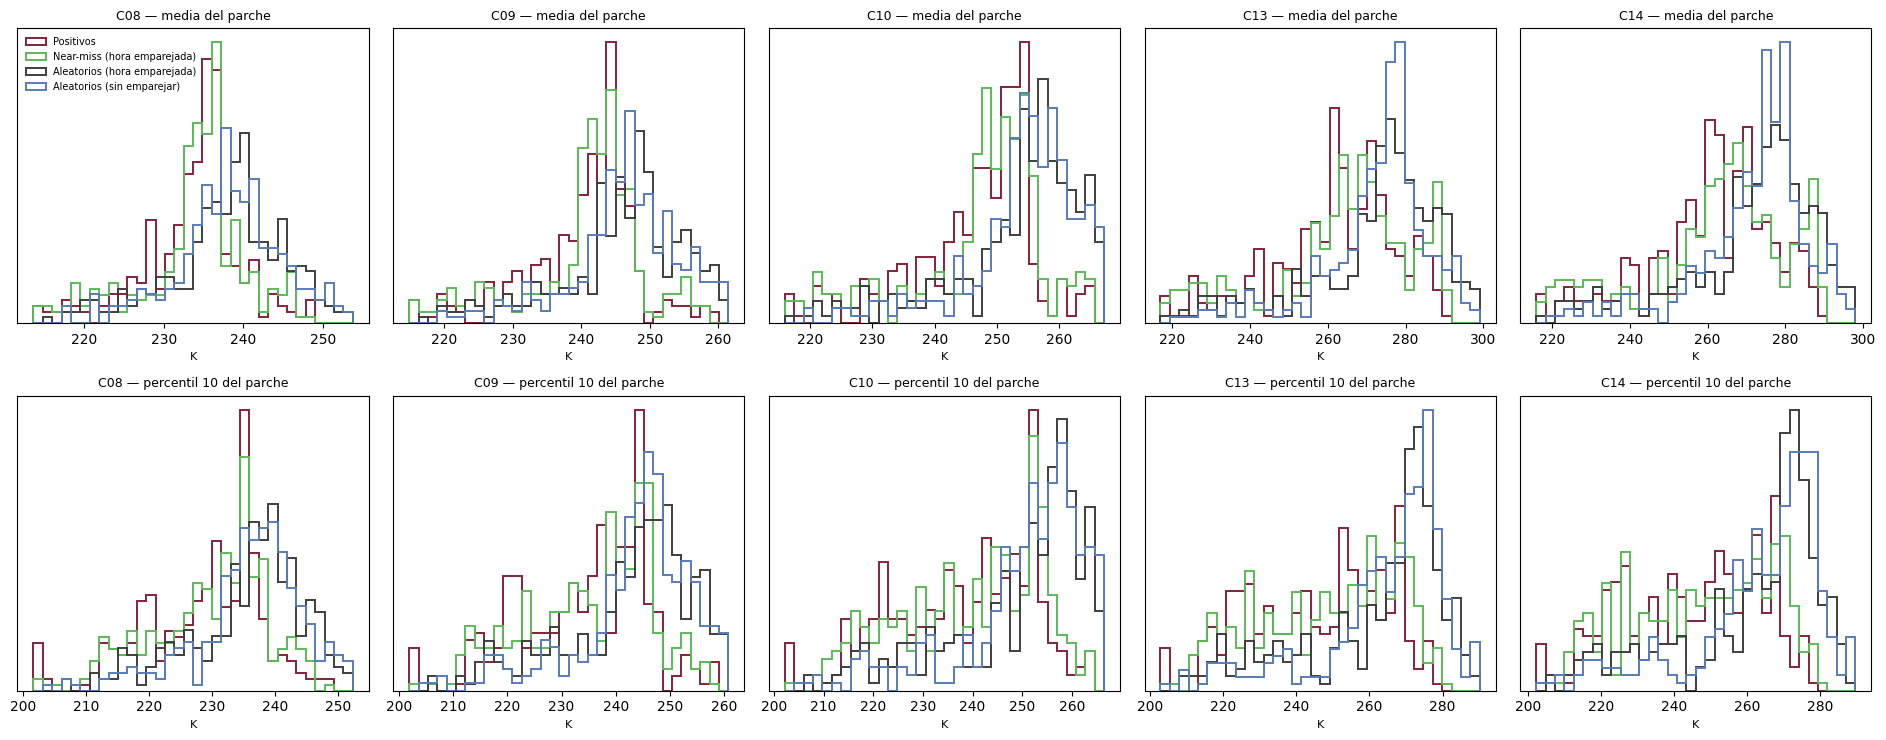

In [40]:
fig, axes = plt.subplots(2, len(BANDAS), figsize=(19, 7.5))
for fila_ax, est in enumerate(["media", "p10"]):
    for k, b in enumerate(BANDAS):
        ax = axes[fila_ax, k]
        v = feat[f"{b[-3:]}_{est}"]
        bins = np.linspace(v.quantile(0.005), v.quantile(0.995), 35)
        for g in GR5:
            ax.hist(v[es_g[g]], bins=bins, density=True, histtype="step", lw=1.4, color=COL5[g], label=ETQ5[g])
        ax.set_title(f"{b[-3:]} — {'media del parche' if est == 'media' else 'percentil 10 del parche'}", fontsize=9)
        ax.set_xlabel("K", fontsize=8)
        ax.set_yticks([])
axes[0, 0].legend(fontsize=7, frameon=False, loc="upper left")
plt.tight_layout()
fig.savefig("img-eda-bt_distribucion.png", dpi=200, bbox_inches="tight")
plt.show()

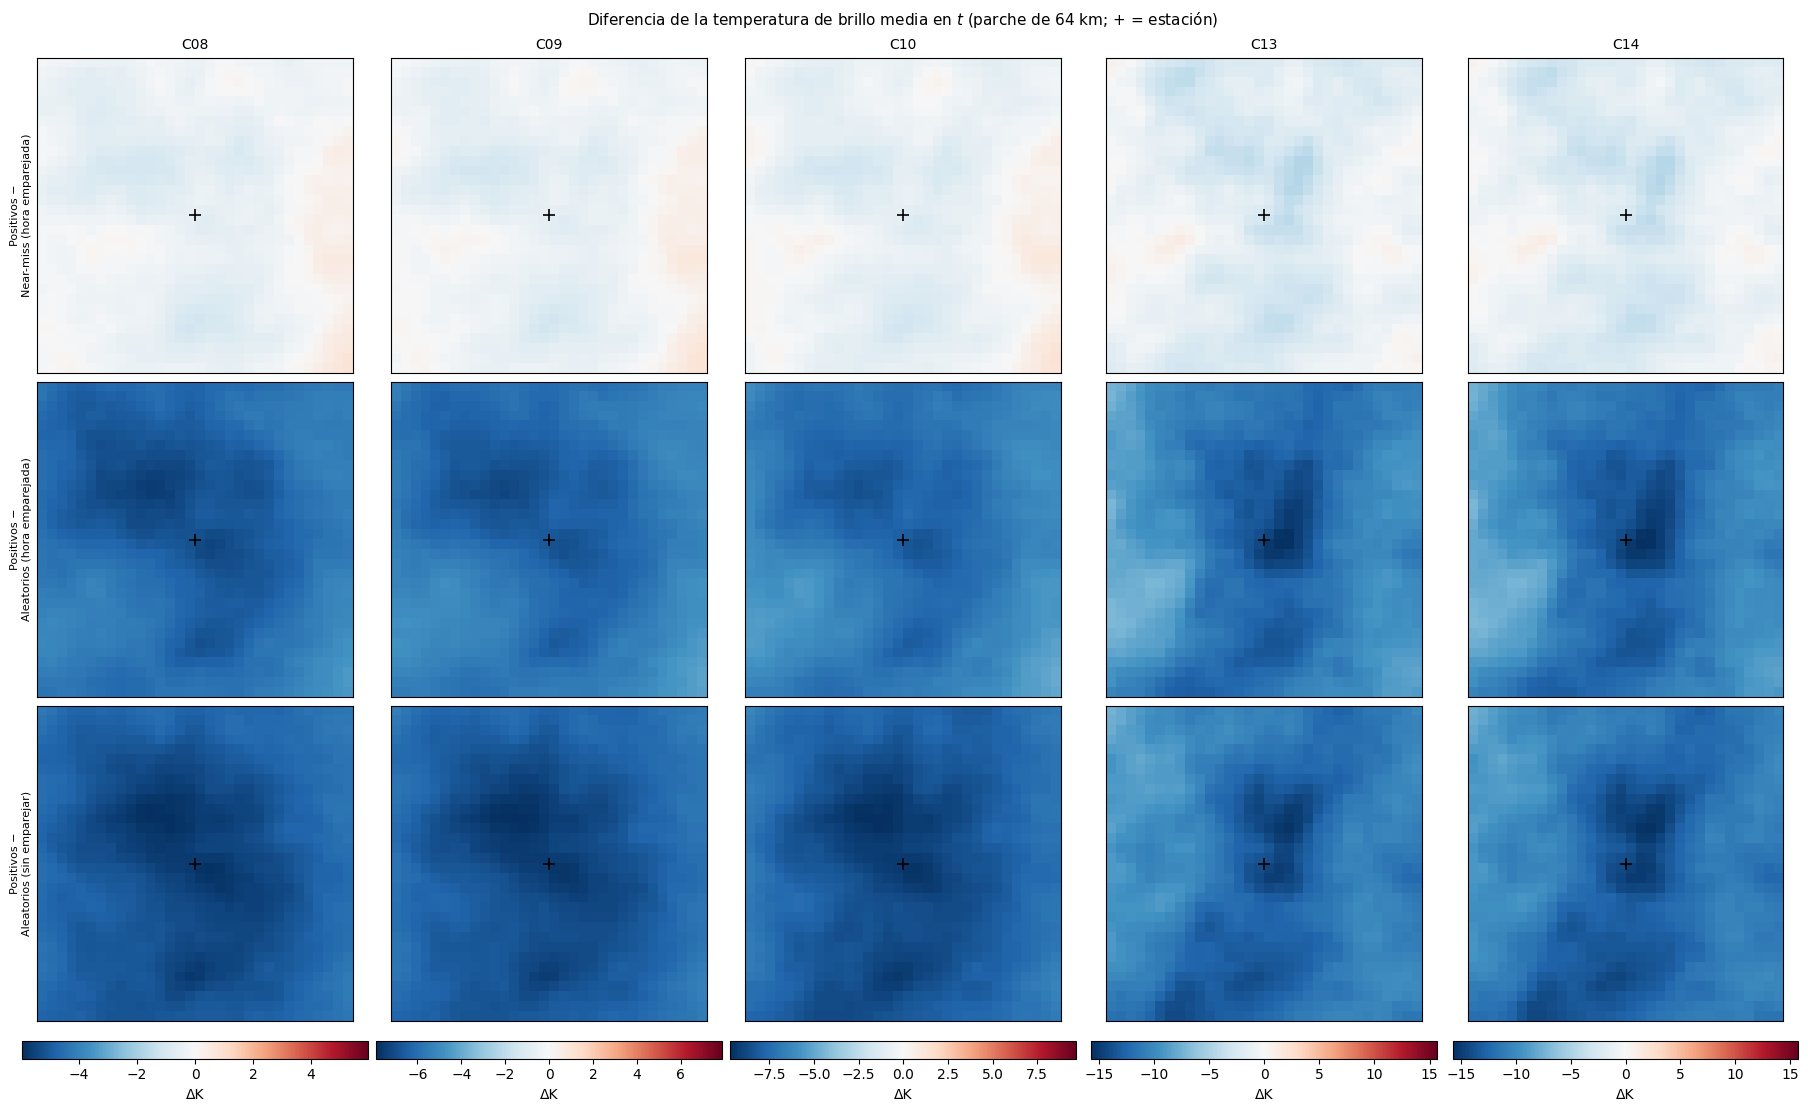

Diferencia media positivos − grupo en el recuadro central (K):
     Near-miss (hora emparejada)  Aleatorios (hora emparejada)  Aleatorios (sin emparejar)
C08                        -0.51                         -5.22                       -5.68
C09                        -0.71                         -6.62                       -7.45
C10                        -1.01                         -7.94                       -9.19
C13                        -3.00                        -14.39                      -13.96
C14                        -2.99                        -14.49                      -14.33


In [41]:
compuesto = {g: np.nanmean(act[es_g[g]], axis=0) for g in GR5}         # (bandas, 32, 32)
negs = GR5[1:]
fig, axes = plt.subplots(len(negs), len(BANDAS), figsize=(18, 11), layout="constrained")
for k, b in enumerate(BANDAS):
    difs = [compuesto["positivo"][k] - compuesto[g][k] for g in negs]
    lim = max(np.nanmax(np.abs(d)) for d in difs)
    for r, (g, d) in enumerate(zip(negs, difs)):
        ax = axes[r, k]
        im = ax.imshow(d, cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax.plot(MITAD - 0.5, MITAD - 0.5, "+", color="black", ms=8, mew=1.2)
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(b[-3:], fontsize=10)
        if k == 0:
            ax.set_ylabel(f"Positivos −\n{ETQ5[g]}", fontsize=8)
    fig.colorbar(im, ax=axes[:, k], orientation="horizontal", fraction=0.04, pad=0.02, label="ΔK")
fig.suptitle("Diferencia de la temperatura de brillo media en $t$ (parche de 64 km; + = estación)", fontsize=11)
fig.savefig("img-eda-bt_diferencia.png", dpi=200, bbox_inches="tight")
plt.show()

print("Diferencia media positivos − grupo en el recuadro central (K):")
print(pd.DataFrame({ETQ5[g]: {b[-3:]: float(np.nanmean((compuesto['positivo'][k] - compuesto[g][k])[CEN, CEN]))
                              for k, b in enumerate(BANDAS)} for g in negs}).round(2).to_string())

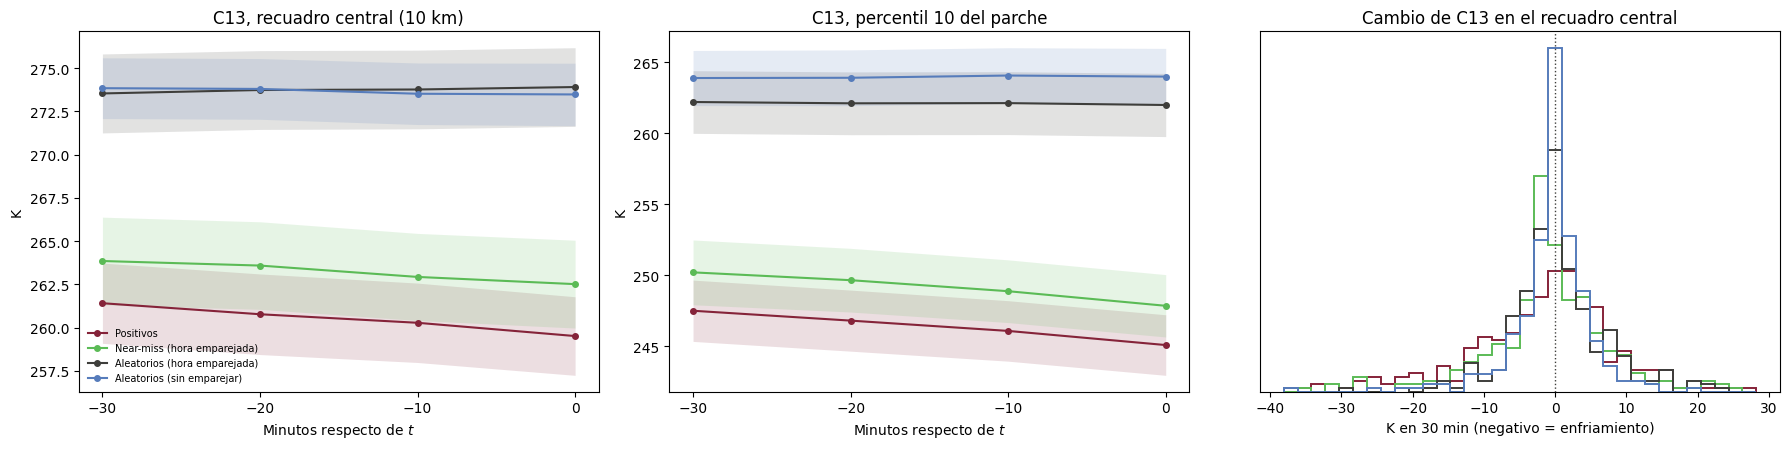

Cambio en 30 min, por grupo (K):
                ΔC13_centro_30min           ΔC13_p10_30min          
                              0.1  0.5  0.9            0.1  0.5  0.9
grupo                                                               
positivo                    -15.6 -0.5  9.5          -11.2 -0.9  4.4
near_miss                   -11.7 -1.1  8.4          -11.3 -0.9  4.6
aleatorio                    -6.6 -0.3  8.5           -3.9 -0.0  4.1
aleatorio_libre              -5.9 -0.1  5.0           -3.0  0.1  4.3


In [42]:
minutos = [-(L_MAX - 1 - j) * PASO_MIN for j in range(L_MAX)]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
for ax, serie, titulo in [(axes[0], centro_lag, "C13, recuadro central (10 km)"),
                          (axes[1], p10_lag, "C13, percentil 10 del parche")]:
    for g in GR5:
        s = serie[es_g[g]]
        m, se = np.nanmean(s, axis=0), np.nanstd(s, axis=0) / np.sqrt(np.sum(~np.isnan(s), axis=0))
        ax.plot(minutos, m, "o-", ms=4, color=COL5[g], label=ETQ5[g])
        ax.fill_between(minutos, m - 1.96 * se, m + 1.96 * se, color=COL5[g], alpha=0.15, lw=0)
    ax.set_xticks(minutos); ax.set_xlabel("Minutos respecto de $t$"); ax.set_ylabel("K")
    ax.set_title(titulo)
axes[0].legend(fontsize=7, frameon=False)

ax = axes[2]
v = feat["ΔC13_centro_30min"]
bins = np.linspace(v.quantile(0.005), v.quantile(0.995), 35)
for g in GR5:
    ax.hist(v[es_g[g]], bins=bins, density=True, histtype="step", lw=1.4, color=COL5[g], label=ETQ5[g])
ax.axvline(0, color=ROL["linea_ref"], ls=":", lw=1)
ax.set_yticks([]); ax.set_xlabel("K en 30 min (negativo = enfriamiento)")
ax.set_title("Cambio de C13 en el recuadro central")
plt.tight_layout()
fig.savefig("img-eda-bt_evolucion.png", dpi=200, bbox_inches="tight")
plt.show()

print("Cambio en 30 min, por grupo (K):")
print(feat.groupby(muestra["grupo"])[["ΔC13_centro_30min", "ΔC13_p10_30min"]]
          .quantile([0.1, 0.5, 0.9]).unstack().reindex(GR5).round(1).to_string())

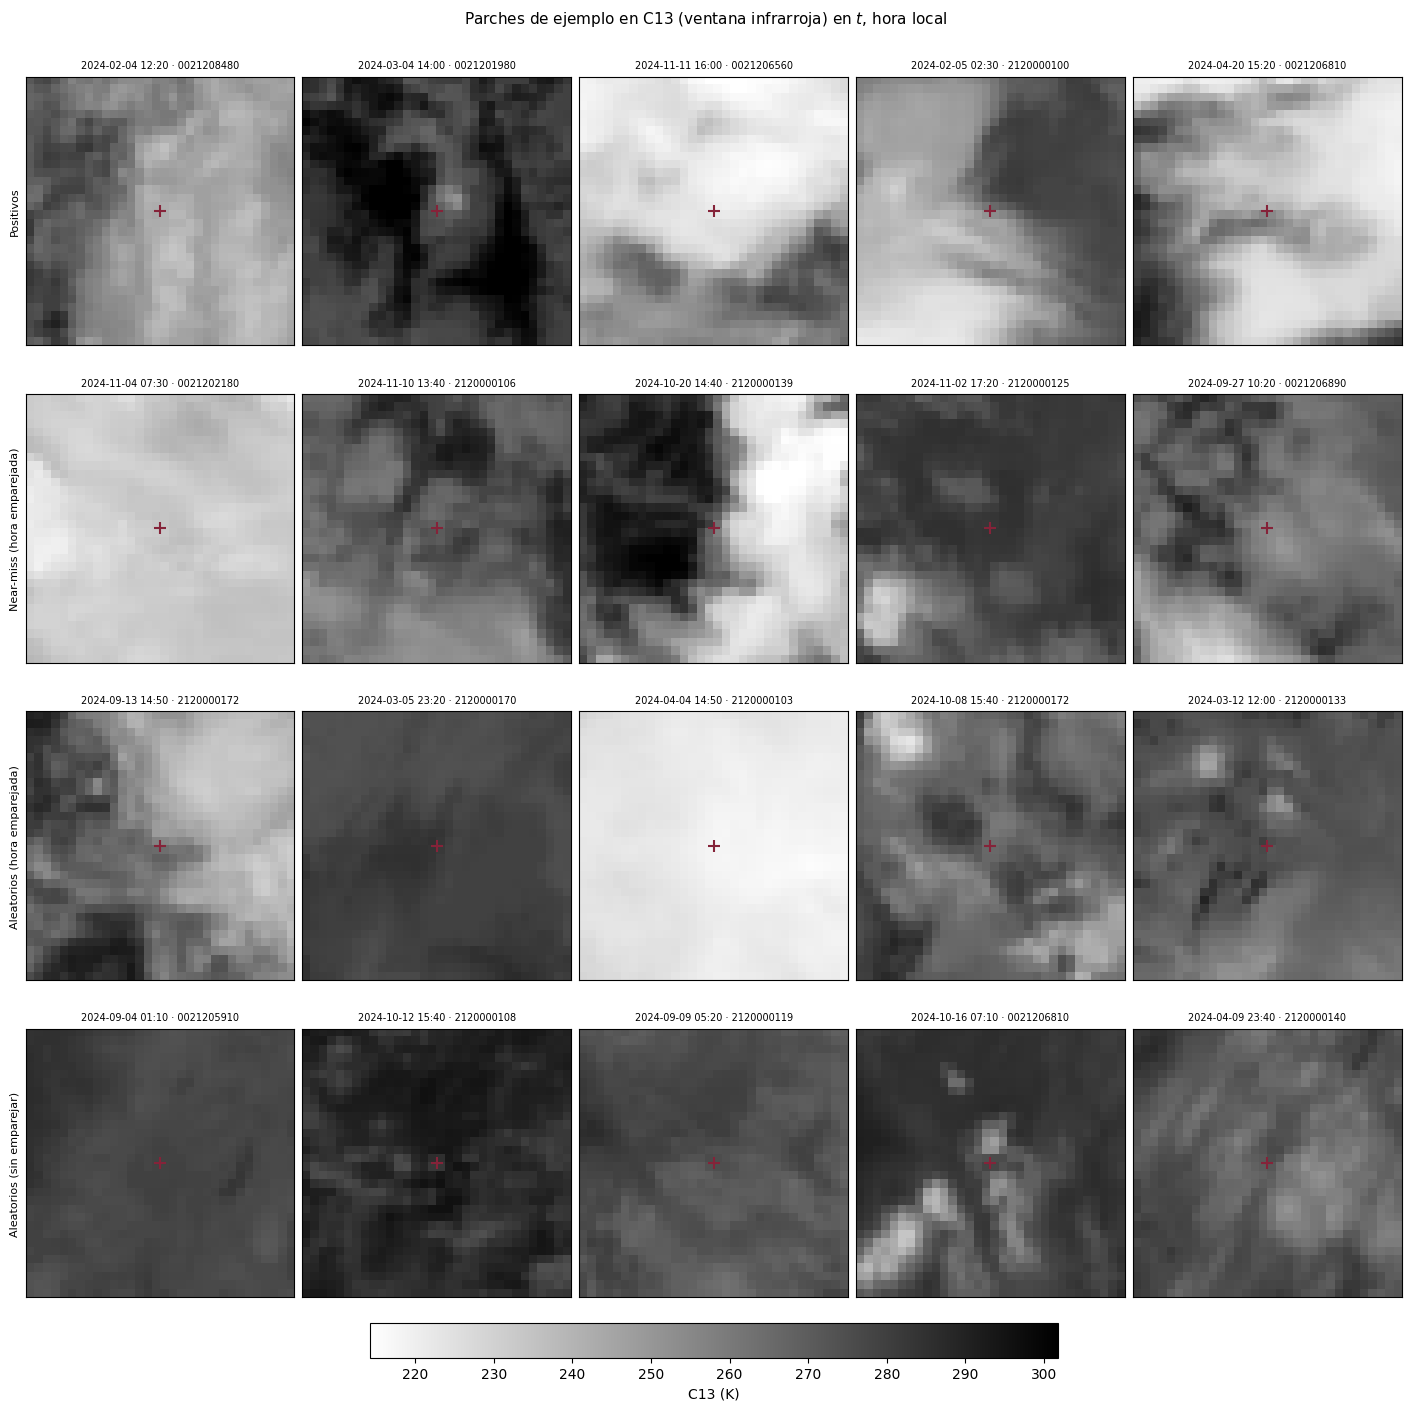

In [43]:
N_EJ = 5
rng  = np.random.default_rng(SEED)
c13  = act[:, K13]
vmin, vmax = np.nanpercentile(c13, [1, 99])
fig, axes = plt.subplots(len(GR5), N_EJ, figsize=(14, 14), layout="constrained")
for r, g in enumerate(GR5):
    for j, i in enumerate(rng.choice(np.flatnonzero(es_g[g]), N_EJ, replace=False)):
        ax = axes[r, j]
        im = ax.imshow(c13[i], cmap="gray_r", vmin=vmin, vmax=vmax)
        ax.plot(MITAD - 0.5, MITAD - 0.5, "+", color=ROL["positivo"], ms=9, mew=1.5)
        m = muestra.loc[i]
        ax.set_title(f"{m['t_local']:%Y-%m-%d %H:%M} · {m['codigoestacion']}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(ETQ5[g], fontsize=8)
fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.03, pad=0.02, shrink=0.5, label="C13 (K)")
fig.suptitle("Parches de ejemplo en C13 (ventana infrarroja) en $t$, hora local", fontsize=11)
fig.savefig("img-eda-ejemplos.png", dpi=200, bbox_inches="tight")
plt.show()

**Resultado.** La señal satelital distingue claramente a los positivos de los negativos aleatorios tomados a la misma hora. En el recuadro central, los positivos son 14.4 K más fríos en C13 y 14.5 K en C14, y entre 5.2 y 7.9 K más fríos en las bandas de vapor de agua (C08 a C10). Todas las variables resumen superan un AUC de 0.70. Las más discriminantes son el percentil 10 del parche en C13 (0.756) y en C14 (0.752), que representan la fracción más fría de la escena. Los mapas compuestos muestran que las dos señales tienen escalas distintas. En las bandas de ventana infrarroja, la anomalía fría es máxima en torno a la estación, mientras que en las de vapor de agua se extiende a todo el parche, lo que indica que los positivos ocurren en escenas con mayor humedad o nubosidad alta a escala de decenas de kilómetros.

El emparejamiento por hora explica una parte menor de esta separación. Frente a los aleatorios sin emparejar, los AUC aumentan entre 0.01 y 0.04 (de 0.756 a 0.792 en el percentil 10 de C13), pero la diferencia en el recuadro central se mantiene prácticamente igual (13.96 K en C13). La señal que separa a los positivos de los aleatorios corresponde, por tanto, a la escena y no al ciclo diurno.

Frente a los near-miss, en cambio, las mismas variables apenas separan los grupos. Los AUC se sitúan entre 0.525 y 0.546. Los positivos son solo 3.0 K más fríos en C13 y C14 en el recuadro central, y entre 0.5 y 1.0 K en las bandas de vapor de agua, y el mapa compuesto de la diferencia es prácticamente uniforme. Los near-miss comparten con los positivos la hora, el día y la escena convectiva (Sección 4), y su temperatura de brillo es casi indistinguible a la escala de las variables resumen.

La evolución durante la media hora previa a $t$ ofrece una conclusión similar. Los positivos y los near-miss se enfrían en promedio entre 1.3 y 2.4 K en 30 minutos, mientras que los aleatorios se mantienen estables, y la distribución del cambio es amplia en los dos primeros grupos. El 10% de los positivos se enfría más de 15.6 K en el recuadro central, pero otro 10% se calienta más de 9.5 K, lo que corresponde a sistemas que se desplazan o se disipan sobre la estación. El cambio separa moderadamente a los positivos de los aleatorios (AUC de 0.600 para el percentil 10 de C13), pero no de los near-miss (0.504 y 0.509). Los ejemplos de la figura muestran, además, que algunos positivos se toman sobre escenas sin nubosidad fría sobre la estación, en las que la convección que producirá la lluvia fuerte aún no se ha formado en $t$.

Estos resultados delimitan el problema que debe resolver el modelo. Distinguir una escena convectiva de una que no lo es está al alcance de variables tan simples como la fracción fría del parche. Decidir cuál de las estaciones bajo una misma escena convectiva registrará lluvia fuerte, en cambio, no se resuelve con promedios del parche ni con la tendencia del centro. La información que permita hacerlo, si existe en las imágenes, se encuentra en la estructura espacial de la escena y en su evolución, que es lo que la red convolucional puede aprovechar. Las cifras provienen de una muestra de 300 pares por grupo, agrupada en 43 días en el caso de los positivos y los near-miss, por lo que describen tendencias y no constituyen estimaciones precisas.

In [44]:
# Cifras citadas en el texto de la Sección 5
dif = pd.DataFrame({g: {b[-3:]: float(np.nanmean((compuesto["positivo"][k] - compuesto[g][k])[CEN, CEN]))
                        for k, b in enumerate(BANDAS)} for g in negs}).round(2)
assert dif["aleatorio"].round(1).tolist() == [-5.2, -6.6, -7.9, -14.4, -14.5]
assert dif["aleatorio_libre"]["C13"] == -13.96
assert dif["near_miss"][["C13", "C14"]].round(1).tolist() == [-3.0, -3.0]
assert dif["near_miss"][["C08", "C09", "C10"]].round(1).tolist() == [-0.5, -0.7, -1.0]
a = auc.round(3)
nivel = [c for c in a.index if not c.startswith("Δ")]
assert (a.loc[nivel, "pos vs aleatorio"] > 0.70).all()
assert (a.loc["C13_p10", "pos vs aleatorio"], a.loc["C14_p10", "pos vs aleatorio"], a.loc["C13_p10", "pos vs aleatorio_libre"]) == (0.756, 0.752, 0.792)
assert (a.loc[nivel, "pos vs aleatorio_libre"] - a.loc[nivel, "pos vs aleatorio"]).between(0.0, 0.04).all()
assert (a.loc[nivel, "pos vs near_miss"].min(), a.loc[nivel, "pos vs near_miss"].max()) == (0.525, 0.546)
assert (a.loc["ΔC13_p10_30min", "pos vs aleatorio"], a.loc["ΔC13_centro_30min", "pos vs near_miss"], a.loc["ΔC13_p10_30min", "pos vs near_miss"]) == (0.600, 0.504, 0.509)
m = medias.round(1)
assert m.loc[["ΔC13_centro_30min", "ΔC13_p10_30min"], ["positivo", "near_miss"]].values.min() == -2.4
assert m.loc[["ΔC13_centro_30min", "ΔC13_p10_30min"], ["positivo", "near_miss"]].values.max() == -1.3
q = feat.groupby(muestra["grupo"])["ΔC13_centro_30min"].quantile([0.1, 0.9]).unstack().round(1)
assert q.loc["positivo"].tolist() == [-15.6, 9.5]
assert muestra.loc[muestra["grupo"].isin(["positivo", "near_miss"])].groupby("grupo")["dia"].nunique().tolist() == [43, 43]
print("Cifras de la Sección 5 verificadas")

Cifras de la Sección 5 verificadas


Positivos nocturnos de entrenamiento con historia completa: 743 (23 días)
           pares  pct_19_23h  dias  estaciones
grupo                                         
positivo     300        51.7    22          44
near_miss    300        51.7    22          61
aleatorio    300        51.7   157          54


Imágenes: 100%|██████████| 1433/1433 [00:27<00:00, 52.20it/s]


Parches guardados en eda_parches_noche.npz

Medias por grupo, noche (K):
grupo              positivo  near_miss  aleatorio
C08_media             231.3      229.6      237.1
C08_p10               227.4      225.7      234.8
C09_media             237.0      234.8      244.8
C09_p10               231.5      229.4      241.8
C10_media             242.1      239.5      252.0
C10_p10               234.3      232.1      248.2
C13_media             251.4      248.6      267.3
C13_p10               239.2      236.7      259.9
C14_media             250.2      247.2      266.4
C14_p10               238.1      235.6      259.0
C13_centro            252.0      248.0      267.9
ΔC13_centro_30min      -0.2       -0.7        0.1
ΔC13_p10_30min         -1.5        0.2        0.1

AUC: muestra general (Sección 5) frente a muestra nocturna:
                           general                             noche                 
                  pos vs near_miss pos vs aleatorio pos vs near_miss pos vs alea

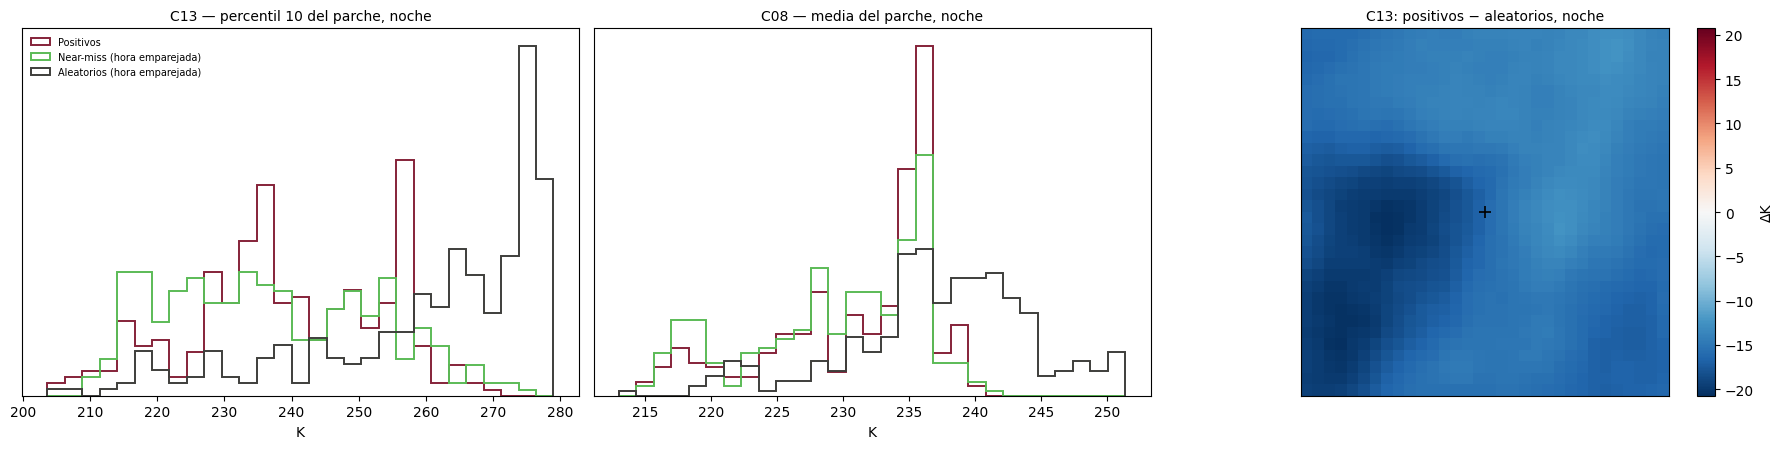

In [51]:
# ============================================================
# Sección 5 — Señal satelital de los positivos nocturnos
# ============================================================
RUTA_CACHE_N = RUTA_BASE / "data" / "eda_parches_noche.npz"
GR_N = ["positivo", "near_miss", "aleatorio"]

base_n = base[(base["hora"] >= 19) | (base["hora"] <= 6)]
pos_n  = base_n[base_n["pool"] == "positivo"]
print(f"Positivos nocturnos de entrenamiento con historia completa: {len(pos_n):,} "
      f"({pos_n['dia'].nunique()} días)")

def muestrear_noche(pool, ref):
    # Emparejamiento exacto por hora con la muestra nocturna de positivos
    d = base_n[base_n["pool"] == pool]
    return pd.concat([d[d["hora"] == h].sample(n, random_state=SEED)
                      for h, n in ref["hora"].value_counts().items()])

pos_mn  = pos_n.sample(min(N_GRUPO, len(pos_n)), random_state=SEED)
muestra_n = pd.concat([pos_mn.assign(grupo="positivo"),
                       muestrear_noche("near_miss", pos_mn).assign(grupo="near_miss"),
                       muestrear_noche("aleatorio", pos_mn).assign(grupo="aleatorio")], ignore_index=True)
print(muestra_n.groupby("grupo", sort=False).agg(
    pares=("hora", "size"), pct_19_23h=("hora", lambda h: (h >= 19).mean() * 100),
    dias=("dia", "nunique"), estaciones=("codigoestacion", "nunique")).round(1).to_string())

clave_n = (muestra_n["codigoestacion"] + "|" + muestra_n["timestamp"].astype(str) + "|" + muestra_n["grupo"]).to_numpy(dtype=str)
if RUTA_CACHE_N.exists() and np.array_equal(np.load(RUTA_CACHE_N)["clave"], clave_n):
    parches_n = np.load(RUTA_CACHE_N)["parches"]
    print(f"Parches leídos de {RUTA_CACHE_N.name}")
else:
    parches_n = extraer(muestra_n)
    np.savez_compressed(RUTA_CACHE_N, parches=parches_n, clave=clave_n)
    print(f"Parches guardados en {RUTA_CACHE_N.name}")
assert 150 < np.nanmin(parches_n) and np.nanmax(parches_n) < 340

def variables(p):
    # Mismas variables que en la muestra general de la Sección 5
    a = p[:, -1]
    f = {}
    for k, b in enumerate(BANDAS):
        f[f"{b[-3:]}_media"] = np.nanmean(a[:, k], axis=(1, 2))
        f[f"{b[-3:]}_p10"]   = np.nanpercentile(a[:, k], 10, axis=(1, 2))
    c   = np.nanmean(p[:, :, K13, CEN, CEN], axis=(2, 3))
    p10 = np.nanpercentile(p[:, :, K13], 10, axis=(2, 3))
    f["C13_centro"]        = c[:, -1]
    f["ΔC13_centro_30min"] = c[:, -1] - c[:, 0]
    f["ΔC13_p10_30min"]    = p10[:, -1] - p10[:, 0]
    return pd.DataFrame(f).astype("float64")

feat_n = variables(parches_n)
es_n   = {g: (muestra_n["grupo"] == g).to_numpy() for g in GR_N}
auc_n  = pd.DataFrame({f"pos vs {g}": {v: auc_menor(feat_n.loc[es_n["positivo"], v].to_numpy(),
                                                    feat_n.loc[es_n[g], v].to_numpy()) for v in feat_n.columns}
                       for g in GR_N[1:]})
medias_n = feat_n.groupby(muestra_n["grupo"]).mean().T[GR_N]

print("\nMedias por grupo, noche (K):")
print(medias_n.round(1).to_string())
print("\nAUC: muestra general (Sección 5) frente a muestra nocturna:")
print(pd.concat({"general": auc[["pos vs near_miss", "pos vs aleatorio"]], "noche": auc_n}, axis=1).round(3).to_string())

comp_n = {g: np.nanmean(parches_n[es_n[g], -1], axis=0) for g in GR_N}
print("\nDiferencia media positivos − grupo en el recuadro central (K):")
print(pd.DataFrame({
    f"{g} ({per})": {b[-3:]: float(np.nanmean((cp["positivo"][k] - cp[g][k])[CEN, CEN])) for k, b in enumerate(BANDAS)}
    for per, cp in [("general", compuesto), ("noche", comp_n)] for g in ["near_miss", "aleatorio"]}).round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
for ax, v, tit in [(axes[0], "C13_p10", "C13 — percentil 10 del parche"), (axes[1], "C08_media", "C08 — media del parche")]:
    s = feat_n[v]
    bins = np.linspace(s.quantile(0.005), s.quantile(0.995), 30)
    for g in GR_N:
        ax.hist(s[es_n[g]], bins=bins, density=True, histtype="step", lw=1.4, color=COL5[g], label=ETQ5[g])
    ax.set_title(f"{tit}, noche", fontsize=10); ax.set_xlabel("K"); ax.set_yticks([])
axes[0].legend(fontsize=7, frameon=False, loc="upper left")
ax = axes[2]
d = comp_n["positivo"][K13] - comp_n["aleatorio"][K13]
lim = np.nanmax(np.abs(d))
im = ax.imshow(d, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.plot(MITAD - 0.5, MITAD - 0.5, "+", color="black", ms=8, mew=1.2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("C13: positivos − aleatorios, noche", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, label="ΔK")
plt.tight_layout()
fig.savefig("img-eda-bt_noche.png", dpi=200, bbox_inches="tight")
plt.show()

**Señal nocturna.** Dado que los positivos nocturnos representan el 17.5% de los de entrenamiento pero el 32.1% de los de prueba (Sección 1), y que la muestra general está dominada por imágenes del mediodía, se repite la comparación con una muestra restringida a las imágenes tomadas entre las 19:00 y las 06:00. El entrenamiento contiene 743 positivos nocturnos con historia completa, repartidos en solo 23 días, de modo que la muestra de 300 positivos proviene de 22 días y sus resultados son indicativos.

Frente a los aleatorios de la misma hora, la separación es mayor de noche que en la muestra general: los AUC se sitúan entre 0.742 y 0.822, con el máximo de nuevo en el percentil 10 de C13. En el recuadro central, los positivos son 15.9 K más fríos en C13 y 16.4 K en C14, y entre 5.7 y 9.8 K en las bandas de vapor de agua. La forma de la anomalía, sin embargo, es distinta. En lugar de concentrarse en torno a la estación, como en la muestra general, la anomalía fría ocupa todo el parche, con su máximo alejado de la estación, lo que indica que los positivos nocturnos ocurren bajo sistemas nubosos extensos y no bajo celdas aisladas.

Frente a los near-miss, la relación se invierte. Los AUC se sitúan entre 0.418 y 0.448, por debajo de 0.5, porque de noche los near-miss son más fríos que los positivos: 4.0 K en C13 y 4.1 K en C14 en el recuadro central, y entre 2.1 y 3.6 K en las bandas de vapor de agua. Una nubosidad más fría sobre la estación no indica, por tanto, una mayor probabilidad de lluvia fuerte en las horas siguientes cuando la escena está dominada por un sistema extenso. Su posición respecto de la estación y su evolución pueden ser más informativas que su temperatura, aunque esta muestra no permite verificarlo. La única variable que favorece a los positivos frente a los near-miss es el cambio del percentil 10 de C13 en la media hora previa: los positivos se enfrían 1.5 K en promedio y los near-miss se mantienen estables (AUC de 0.585).

Para el modelado, esto implica que el régimen nocturno, con un peso considerable en la prueba, está representado en entrenamiento por pocos días. Además, en ese régimen la relación entre la temperatura de brillo y la etiqueta difiere de la del mediodía, de modo que una regla basada en la fracción fría de la escena produciría de noche falsas alarmas sistemáticas sobre las estaciones bajo el núcleo de los sistemas.

In [54]:
# Cifras citadas en el texto de la señal nocturna
assert (len(pos_n), pos_n["dia"].nunique()) == (743, 23)
assert muestra_n.loc[muestra_n["grupo"] == "positivo", "dia"].nunique() == 22
an = auc_n.round(3)
niv = [c for c in an.index if not c.startswith("Δ")]
assert (an.loc[niv, "pos vs aleatorio"].min(), an.loc[niv, "pos vs aleatorio"].max()) == (0.742, 0.822)
assert an.loc[niv, "pos vs aleatorio"].idxmax() == "C13_p10"
assert (an.loc[niv, "pos vs near_miss"].min(), an.loc[niv, "pos vs near_miss"].max()) == (0.418, 0.448)
assert an.loc["ΔC13_p10_30min", "pos vs near_miss"] == 0.585
dn = pd.DataFrame({g: {b[-3:]: float(np.nanmean((comp_n["positivo"][k] - comp_n[g][k])[CEN, CEN]))
                       for k, b in enumerate(BANDAS)} for g in ["near_miss", "aleatorio"]})

assert medias_n.round(1).loc["ΔC13_p10_30min", ["positivo", "near_miss"]].tolist() == [-1.5, 0.2]
print("Cifras de la señal nocturna verificadas")

Cifras de la señal nocturna verificadas


## Síntesis

El análisis exploratorio caracteriza un conjunto con un desbalance marcado, de 292 negativos por positivo en entrenamiento, y cuya composición difiere de forma sistemática entre los períodos, lo que condiciona tanto el entrenamiento como la interpretación de la evaluación.

En primer lugar, el entrenamiento y la evaluación no representan los mismos regímenes de lluvia. Los positivos de entrenamiento se concentran en las imágenes del mediodía y en la segunda temporada de lluvias de 2024, con el 41.4% en la primera quincena de noviembre, mientras que la validación y la prueba incluyen una proporción mucho mayor de eventos nocturnos y, en el caso de la prueba, una primera temporada de lluvias que en 2024 fue casi inexistente. La menor cobertura de las estaciones en 2024, con el 48.5% de los instantes posibles frente al 74.7% en 2025, acentúa esta diferencia, puesto que 11 estaciones solo aportan registros del segundo semestre. A ello se suma que el umbral de cada estación, fijado con el año 2024, se supera en 2025 con frecuencias muy distintas entre estaciones (ρ = −0.71 entre el umbral y la tasa de 2025), de modo que la prevalencia del conjunto de prueba es heterogénea y las métricas agregadas pesan más a las estaciones de umbral bajo. Las métricas de prueba deberán interpretarse a la luz de estas diferencias, y su desagregación entre el día y la noche y por grupos de umbral permitiría distinguir el desempeño en cada régimen.

En segundo lugar, el tamaño efectivo del conjunto es mucho menor que el número de pares. Los 4,255 positivos de entrenamiento corresponden a 78 episodios regionales en 49 días, y los 1,542 de validación a 48 episodios en 25 días, en su mayoría de una sola estación. La validación ofrece, por tanto, una base limitada para seleccionar hiperparámetros, y las diferencias pequeñas entre configuraciones medidas sobre ella deben tomarse con cautela. La incertidumbre de las métricas depende de la variabilidad entre días y no entre pares, que no son observaciones independientes.

En tercer lugar, los dos grupos de negativos plantean problemas de dificultad muy distinta. La mitad de los negativos aleatorios son nocturnos y tres de cada cuatro pertenecen a días sin positivos en la red, y frente a ellos los positivos se separan con variables tan simples como la fracción más fría del parche (AUC de 0.756 con la hora emparejada). Los near-miss, en cambio, comparten con los positivos la hora, el día y la escena convectiva, y ni las variables resumen del parche ni su tendencia durante la media hora previa los distinguen (AUC entre 0.50 y 0.55). De noche, la relación incluso se invierte, puesto que los near-miss se encuentran bajo nubosidad más fría que los positivos, de modo que una regla basada en la fracción fría de la escena no solo pierde capacidad de discriminación, sino que produce falsas alarmas sistemáticas. Un muestreo uniforme de los negativos expondría al modelo casi exclusivamente al contraste fácil, dado que los near-miss representan menos del 5% de los negativos de entrenamiento. Su presencia en el muestreo es, por tanto, la que obliga al modelo a aprender el contraste que la tarea requiere.

Por último, los resultados de la señal satelital delimitan lo que se espera de la red convolucional y de la comparación entre historias. Si las imágenes contienen información que permita decidir cuál de las estaciones bajo una misma escena convectiva registrará lluvia fuerte, esa información no está en los promedios del parche ni en la tendencia de su centro, sino en la estructura espacial de la escena y en su evolución. Del mismo modo, la tendencia de 30 minutos resumida en el recuadro central no separa a los positivos de los near-miss, de modo que una eventual ventaja de las historias más largas de la matriz experimental dependerá de que la red extraiga de la secuencia de imágenes patrones de evolución que estas variables simples no capturan.

In [50]:
# Cifras citadas en la síntesis (ya verificadas en sus secciones; se repiten las de mayor peso)
assert comp["neg_por_pos"].round(0).astype(int).tolist()[0] == 292
assert (nov_tr, f"{nov_tr / len(pos_tr):.1%}") == (1760, "41.4%")
assert round(tab.loc["tasa_2025", "rho_umbral"], 2) == -0.71
assert resumen_ep.loc[["train", "val"], ["ep_regionales", "dias_con_positivos"]].values.tolist() == [[78, 49], [48, 25]]
assert auc.round(3).loc["C13_p10", "pos vs aleatorio"] == 0.756
assert auc.loc[:, "pos vs near_miss"].round(2).between(0.50, 0.55).all()
print("Cifras de la síntesis verificadas")

Cifras de la síntesis verificadas
